# Charts Notebook

All visualizations for Tech Pulse. Loads from saved GitHub outputs.

## Prerequisites
Run in order:
1. `A_sentiment_engine.ipynb` → `sentiment_outputs/`
2. `B_correlation_engine.ipynb` → `correlation_outputs/`
3. `C_strategy_engine.ipynb` → `strategy_outputs/`

## Charts in this notebook
| # | Chart | What it shows |
|---|-------|---------------|
| 1 | Sentiment vs Price Lines | Two-line chart: sentiment up/down + % price change |
| 2 | Mood-o-Meter | Mood bars + stock price over time |
| 3 | Key Moment Zoom | Big price moves first, then show preceding sentiment |
| 4 | Four Quadrant | True/False Positive/Negative per ticker |
| 5 | Correlation Bar | Top tickers by sentiment-to-price correlation |
| 6 | Source Contribution | Which data source drives each ticker most |
| 7 | Buzz Leaderboard | Most mentioned companies, colored by tone |
| 8 | Portfolio Growth | All strategies compounding, vs S&P 500 |
| 9 | Strategy Good/Bad Periods | Gradient coloring on portfolio chart |
| 10 | Strategy Selector Heatmap | Age × price stage win rate grid |
| 11 | Lifecycle Analysis | Company age + price stage win rates |
| 12 | Sector Rotation Timeline | Which sector was chosen each week |
| 13 | Absolute vs Relative Sentiment | Fixed — shows z-score of sentiment vs baseline |

---
## 0. Install

In [1]:
# !pip install pandas requests python-dotenv matplotlib seaborn scipy

---
## 1. Configuration & Load All Data

In [2]:
import os, io, requests, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats as scipy_stats
from datetime import datetime, timezone
from dotenv import load_dotenv
load_dotenv()

GITHUB_REPO   = 'annhmartin/dataviz-historical-stocks-AnnetteMartin'
GITHUB_TOKEN  = os.environ.get('GITHUB_TOKEN', None)
OUTPUT_PREFIX = 'sentiment_outputs'
CORR_PREFIX   = 'correlation_outputs'
STRAT_PREFIX  = 'strategy_outputs'
STOCKS_PREFIX = 'stocks'

ANALYSIS_START      = '2015-01-01'
ANALYSIS_END        = datetime.now(timezone.utc).strftime('%Y-%m-%d')
SENTIMENT_THRESHOLD = 0.05
ZSCORE_THRESHOLD    = 2.0

# Tickers to show in multi-ticker charts
# Set to None to auto-select from correlation results, or specify manually
CHART_TICKERS = [
    'NVDA','AAPL','MSFT','GOOGL','META',  # Big Tech
    'CRWD','PANW','PLTR',                  # Your portfolio focus
    'NVO','PM',                            # Portfolio holdings
]  # Change to None to auto-select from B's correlation matrix

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc', 'axes.grid': True,
    'grid.color': '#e8e8e8', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
})

def load_csv(path, token=None):
    url = f'https://raw.githubusercontent.com/{GITHUB_REPO}/main/{path}'
    headers = {'Authorization': f'Bearer {token}'} if token else {}
    resp = requests.get(url, headers=headers, timeout=60)
    if resp.status_code == 404: raise FileNotFoundError(path)
    resp.raise_for_status()
    content = resp.text.strip()
    if not content: return pd.DataFrame()
    return pd.read_csv(io.StringIO(content), low_memory=False)

print('Loading data from GitHub ...')

# Sentiment signals
sig_frames = []
for year in range(int(ANALYSIS_START[:4]), int(ANALYSIS_END[:4])+1):
    for q in [1, 2, 3, 4]:
        try:
            df_y = load_csv(f'{OUTPUT_PREFIX}/daily_signals_{year}_Q{q}.csv', GITHUB_TOKEN)
            sig_frames.append(df_y)
        except FileNotFoundError: pass
# Fallback to yearly files
if not sig_frames:
    for year in range(int(ANALYSIS_START[:4]), int(ANALYSIS_END[:4])+1):
        try:
            df_y = load_csv(f'{OUTPUT_PREFIX}/daily_signals_{year}.csv', GITHUB_TOKEN)
            sig_frames.append(df_y)
        except FileNotFoundError: pass
daily_signals = pd.concat(sig_frames, ignore_index=True) if sig_frames else pd.DataFrame()
if not daily_signals.empty:
    daily_signals['date'] = pd.to_datetime(daily_signals['date'])
    print(f'Signals: {len(daily_signals):,} rows, {daily_signals["ticker"].nunique()} tickers')

# Correlation outputs
try:
    best_per_ticker  = load_csv(f'{CORR_PREFIX}/best_per_ticker.csv',  GITHUB_TOKEN)
    df_key_moves     = load_csv(f'{CORR_PREFIX}/key_moves.csv',        GITHUB_TOKEN)
    df_corr          = load_csv(f'{CORR_PREFIX}/corr_matrix.csv',      GITHUB_TOKEN)
    source_attr      = load_csv(f'{CORR_PREFIX}/source_attribution.csv',GITHUB_TOKEN)
    df_spillover     = load_csv(f'{CORR_PREFIX}/spillover_pairs.csv',  GITHUB_TOKEN)
    print(f'Correlation: {len(best_per_ticker)} tickers, {len(df_key_moves):,} key moves')
except FileNotFoundError as e:
    print(f'Missing correlation data: {e}. Run B_correlation_engine.ipynb first.')
    best_per_ticker = df_key_moves = df_corr = source_attr = df_spillover = pd.DataFrame()

# Strategy outputs
try:
    df_equity  = load_csv(f'{STRAT_PREFIX}/equity_curves.csv', GITHUB_TOKEN)
    df_trades  = load_csv(f'{STRAT_PREFIX}/trade_log.csv',     GITHUB_TOKEN)
    df_equity['date'] = pd.to_datetime(df_equity['date'])
    print(f'Strategy: {len(df_equity)} dates, {len(df_trades)} trades')
except FileNotFoundError:
    df_equity = df_trades = pd.DataFrame()
    print('No strategy data. Run C_strategy_engine.ipynb first.')

# SPY benchmark
try:
    df_spy = load_csv(f'{STOCKS_PREFIX}/prices_SPY.csv', GITHUB_TOKEN)
    df_spy['Date'] = pd.to_datetime(df_spy['Date'])
    df_spy['daily_return'] = df_spy['Close'].pct_change(fill_method=None)
    df_spy = df_spy.set_index('Date').sort_index()
    SPY_AVAILABLE = True
except FileNotFoundError:
    SPY_AVAILABLE = False

# Auto-select chart tickers
if CHART_TICKERS is None and not best_per_ticker.empty:
    CHART_TICKERS = best_per_ticker.head(5)['ticker'].tolist()
elif CHART_TICKERS is None:
    CHART_TICKERS = ['NVDA','AAPL','MSFT','GOOGL','META','CRWD','PANW','PLTR','NVO','PM']

all_tickers = daily_signals['ticker'].unique().tolist() if not daily_signals.empty else []
sig_col = 'adaptive_sentiment' if 'adaptive_sentiment' in daily_signals.columns else 'norm_sentiment'
print(f'\nChart tickers: {CHART_TICKERS}')
print('Ready to run charts!')

Loading data from GitHub ...
Signals: 8,233,536 rows, 1952 tickers
Correlation: 1506 tickers, 23,309 key moves
Strategy: 3497 dates, 218 trades

Chart tickers: ['NVDA', 'AAPL', 'MSFT', 'GOOGL', 'META', 'CRWD', 'PANW', 'PLTR', 'NVO', 'PM']
Ready to run charts!


---
## Chart 1: Sentiment vs Price — Two-Line View

Two synchronized lines per ticker: sentiment score (up/down) and % price change (up/down).
Makes it easy to see whether they move together. Works for any company, not just big ones.

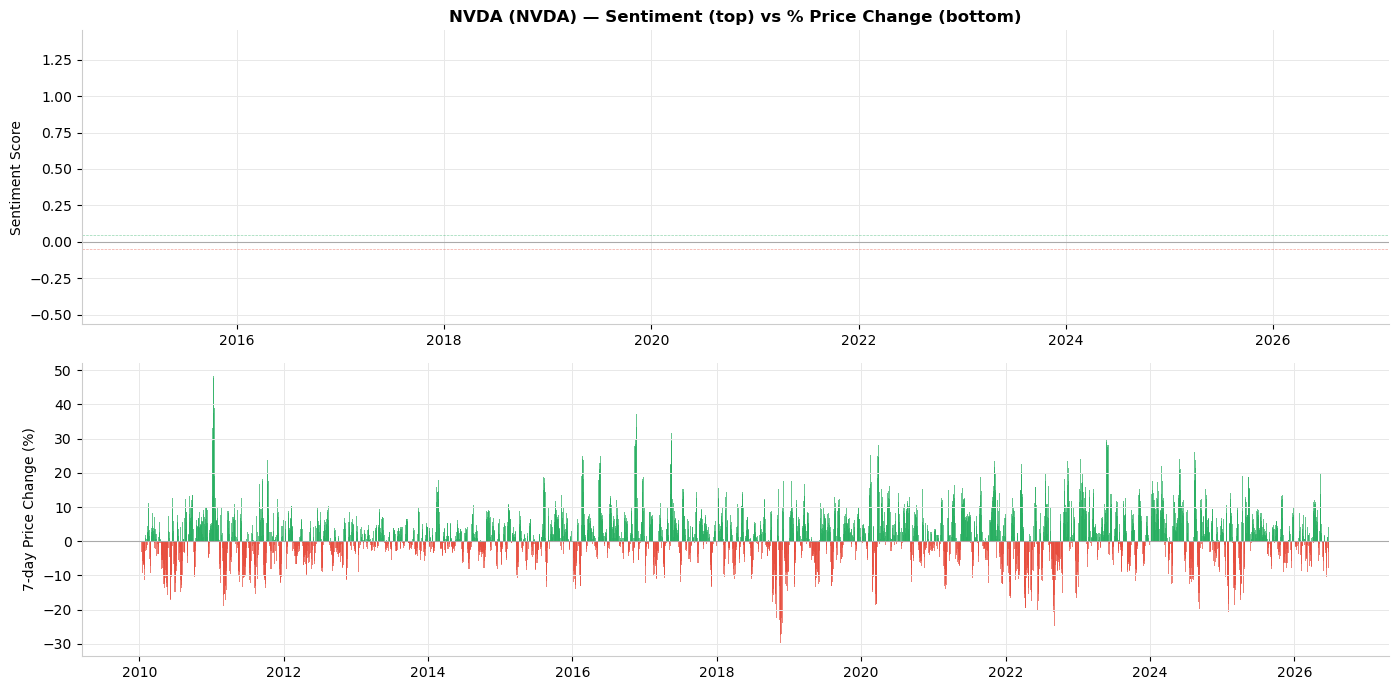

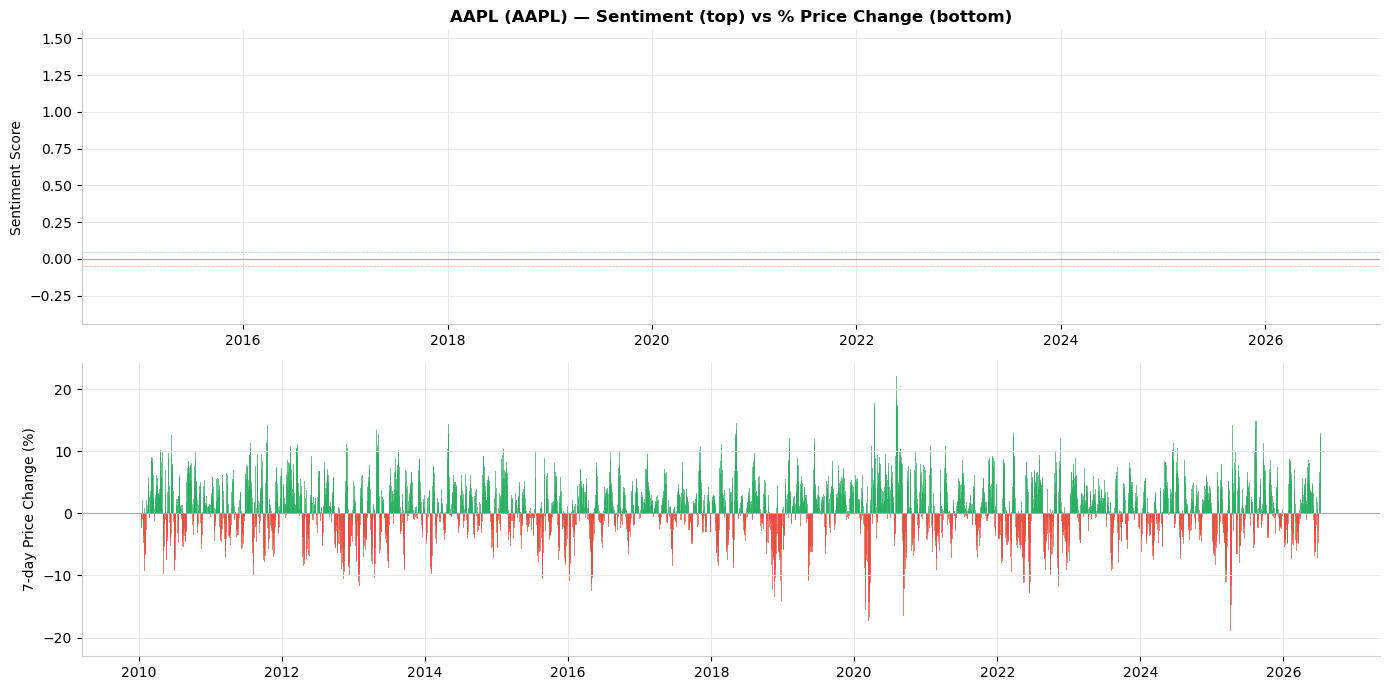

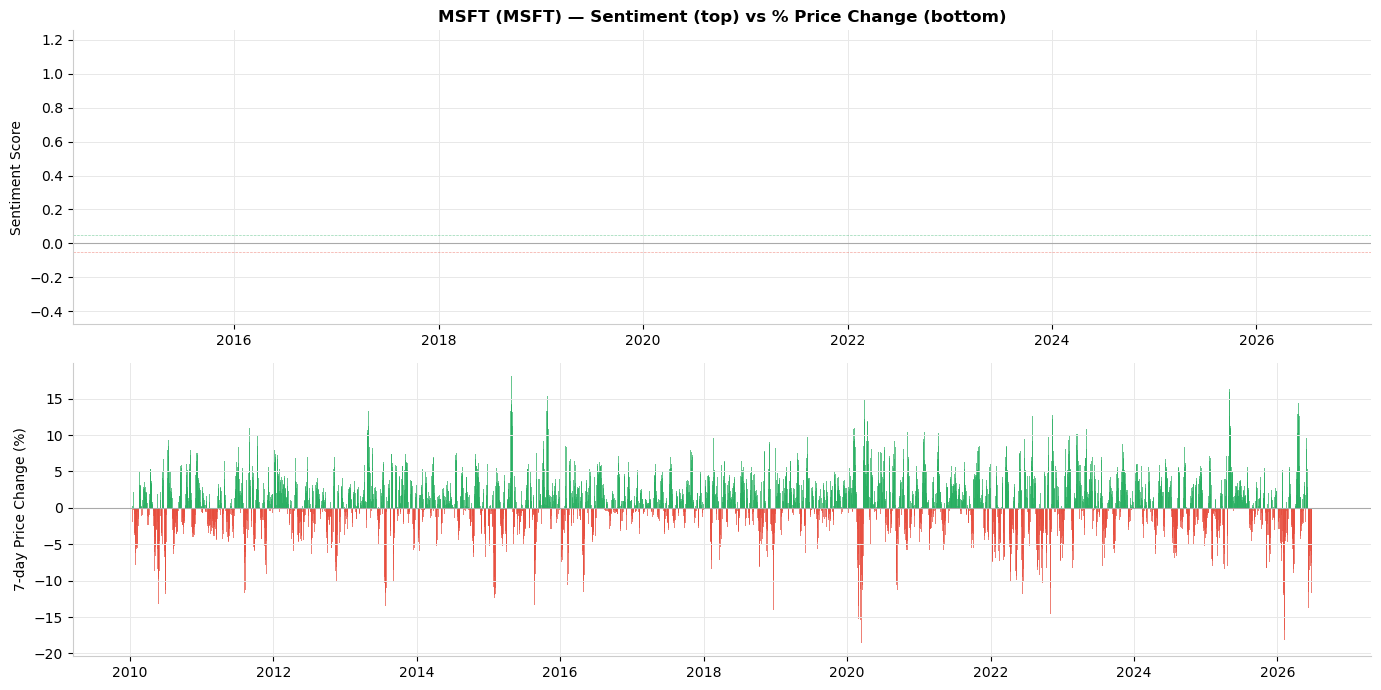

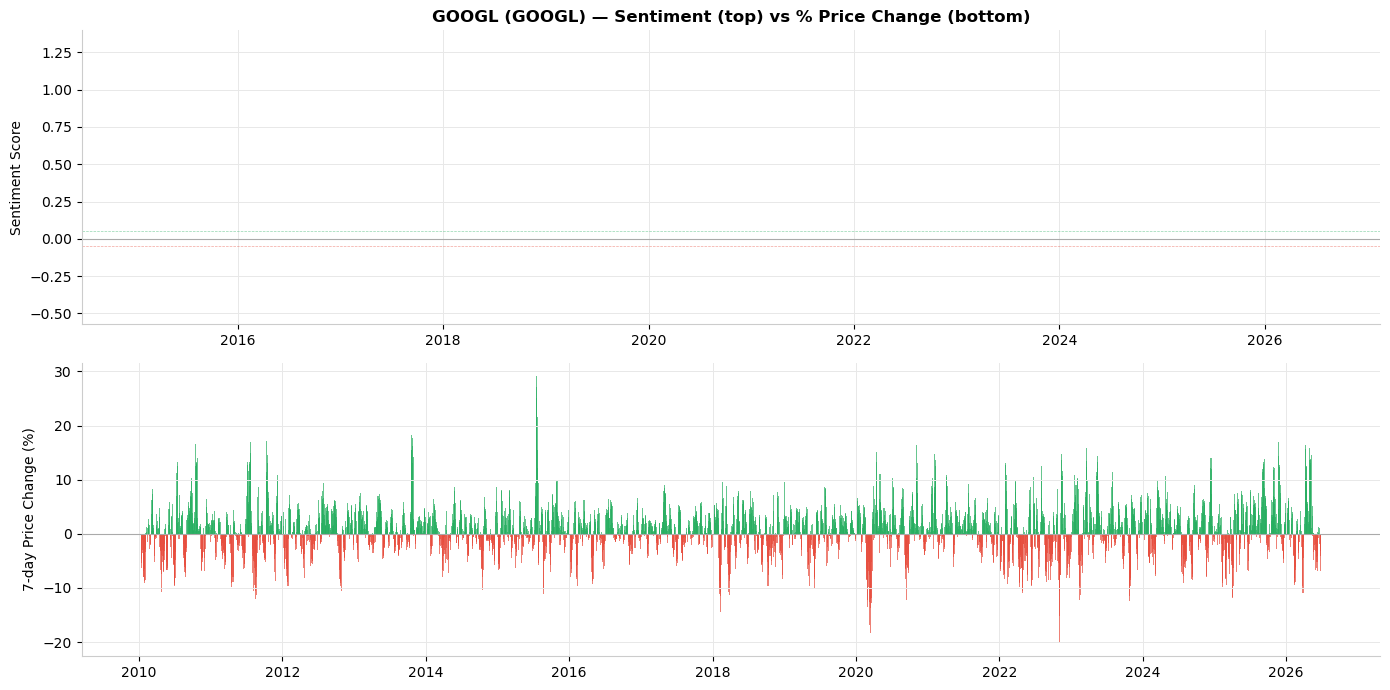

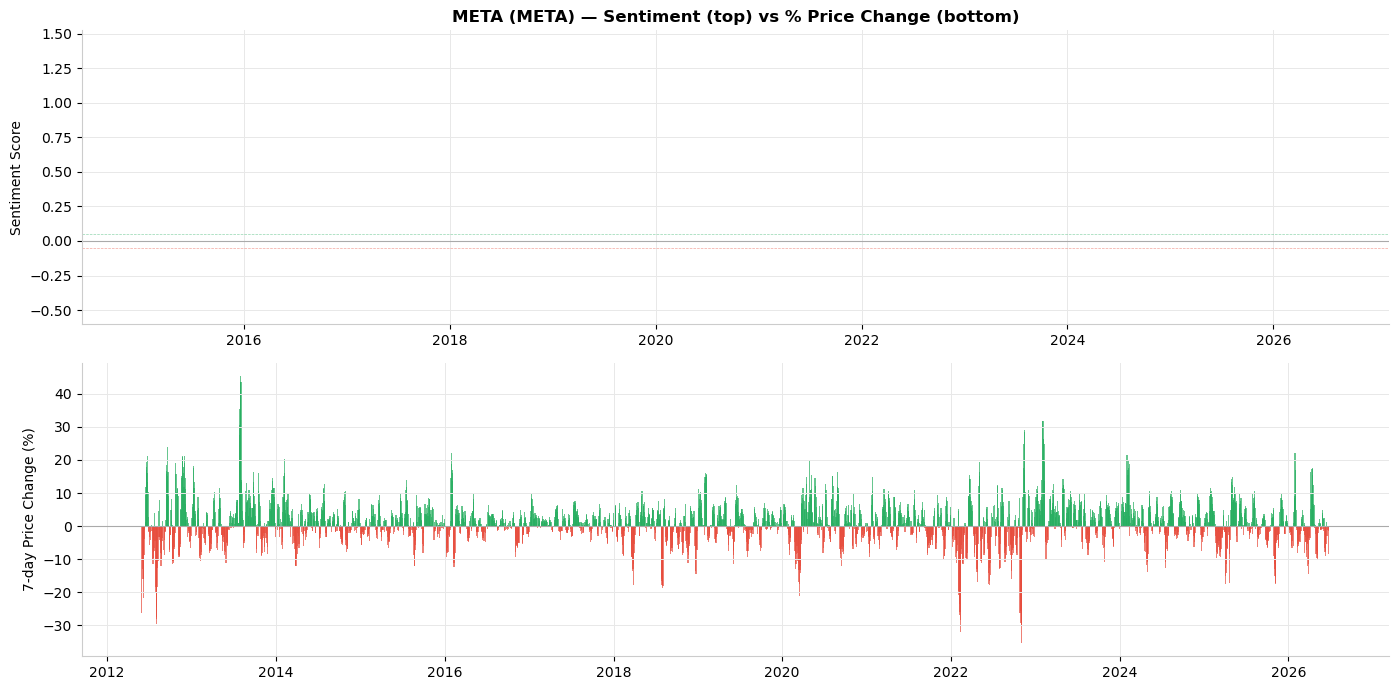

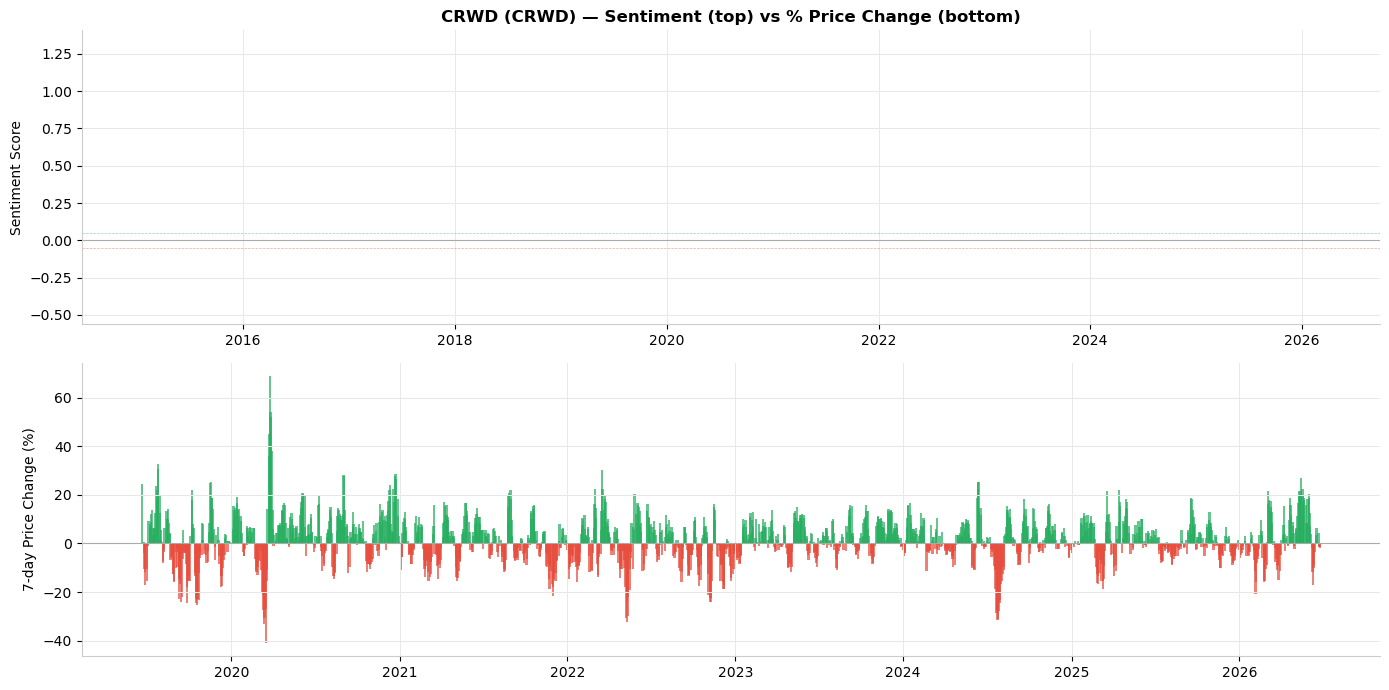

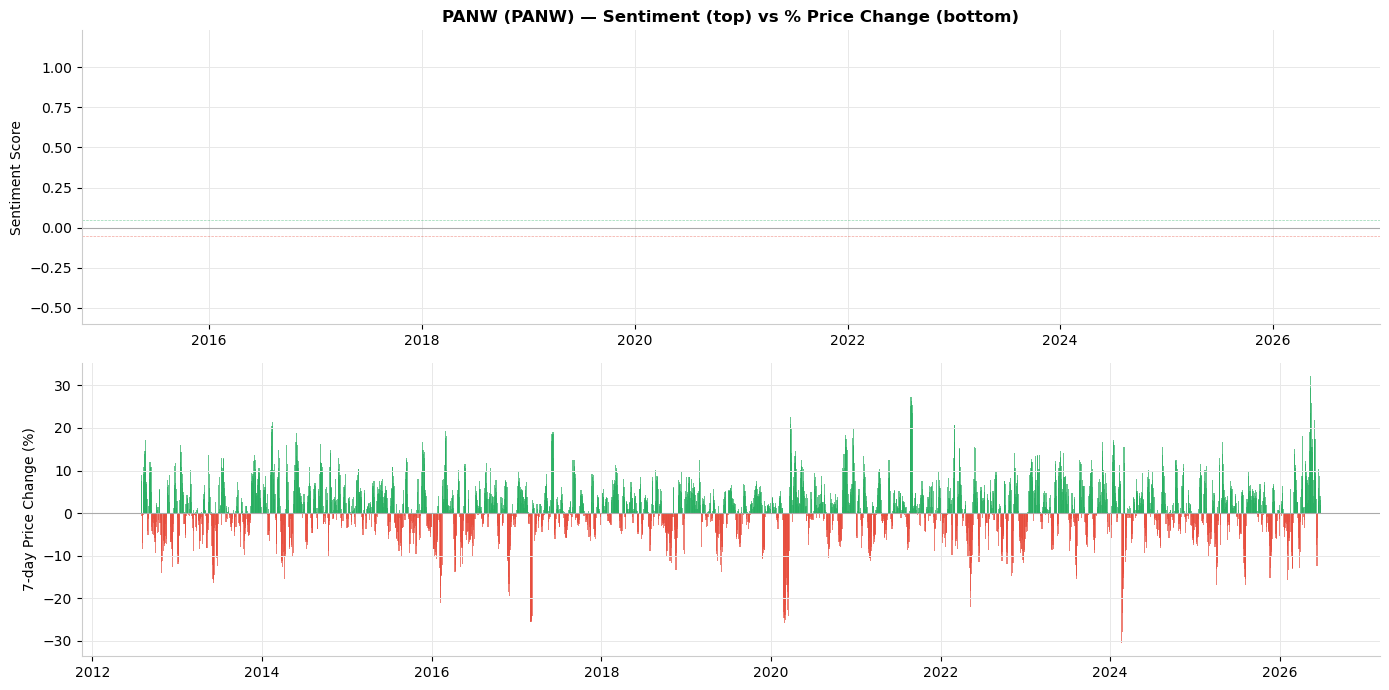

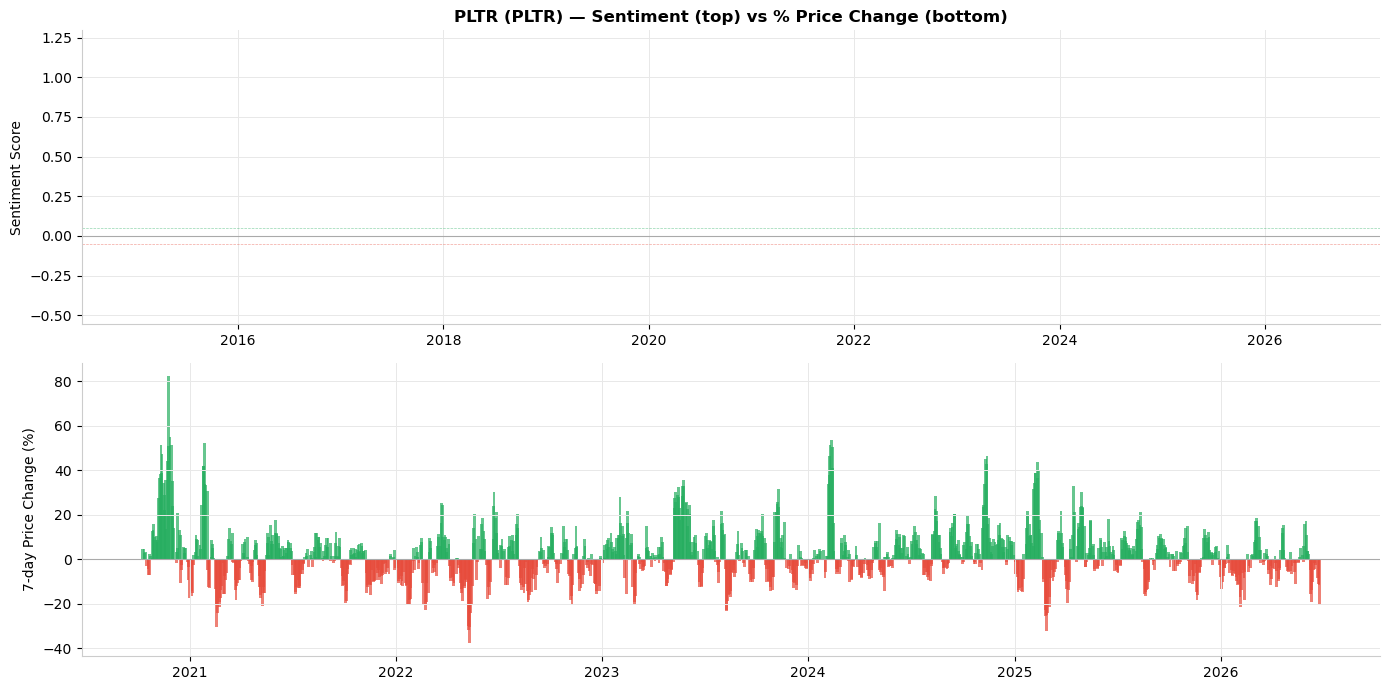

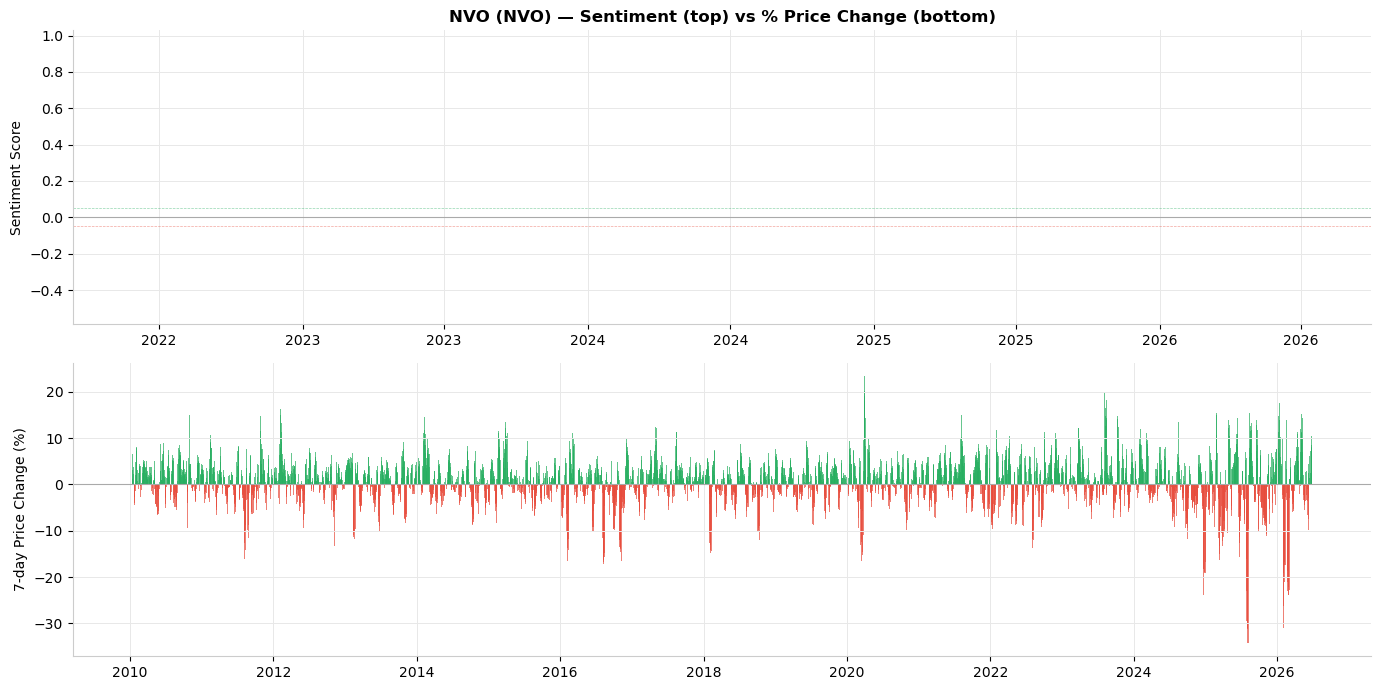

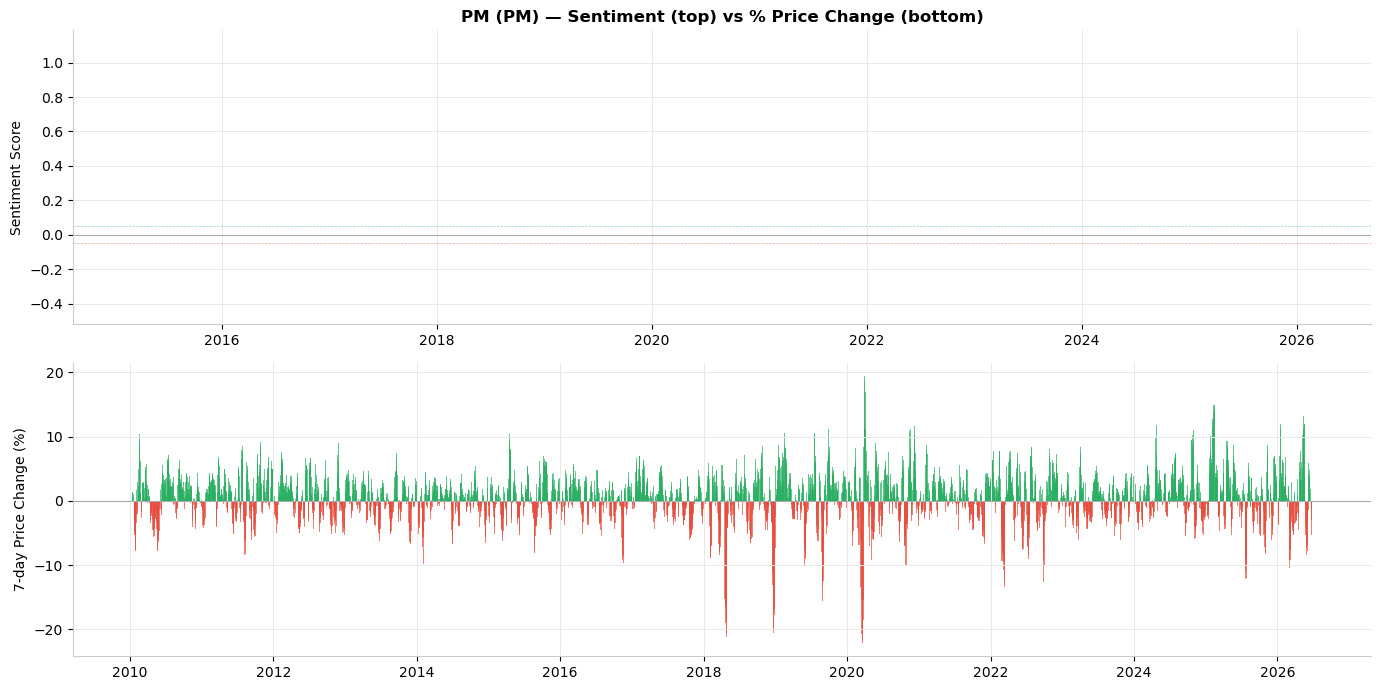

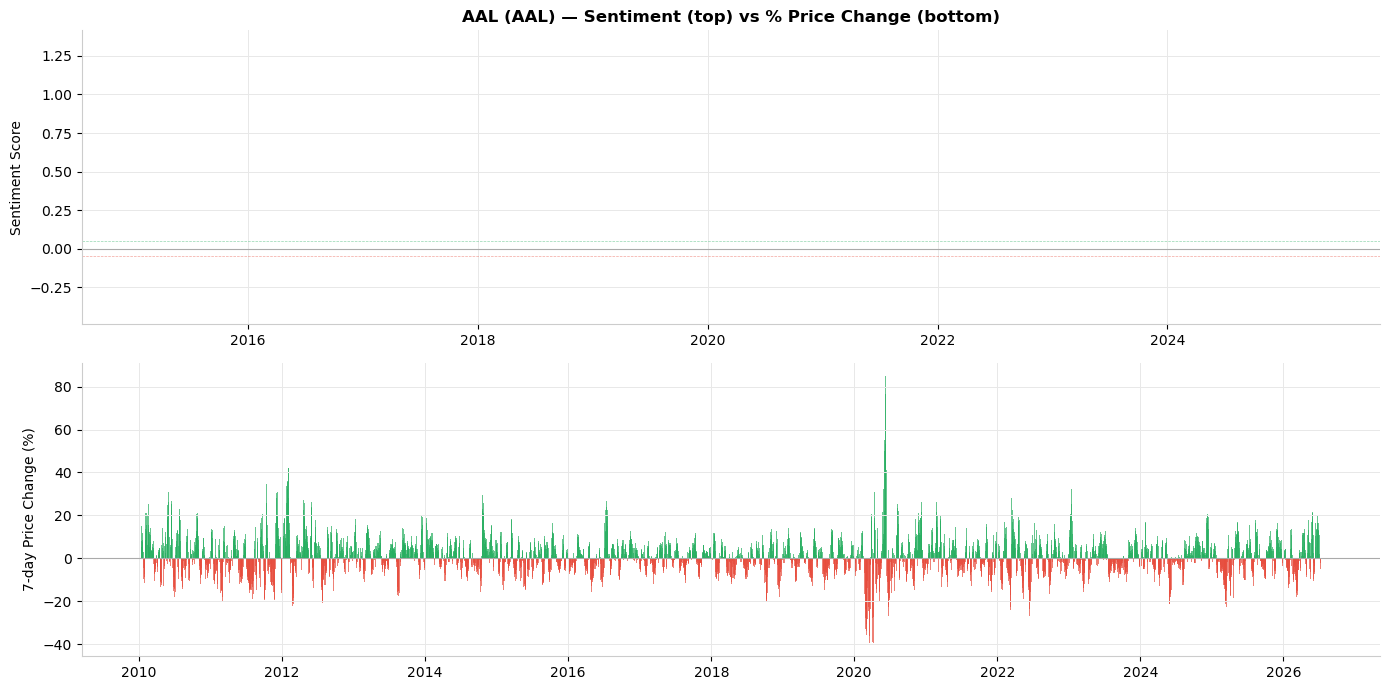

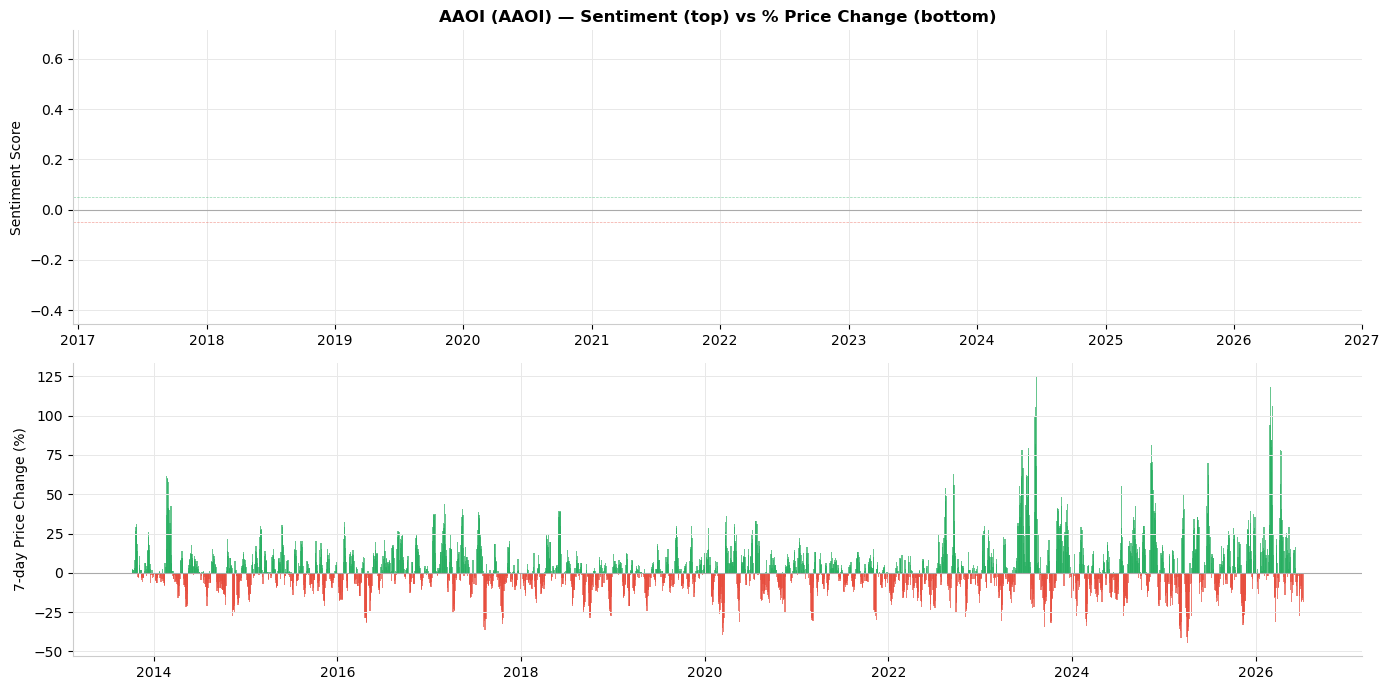

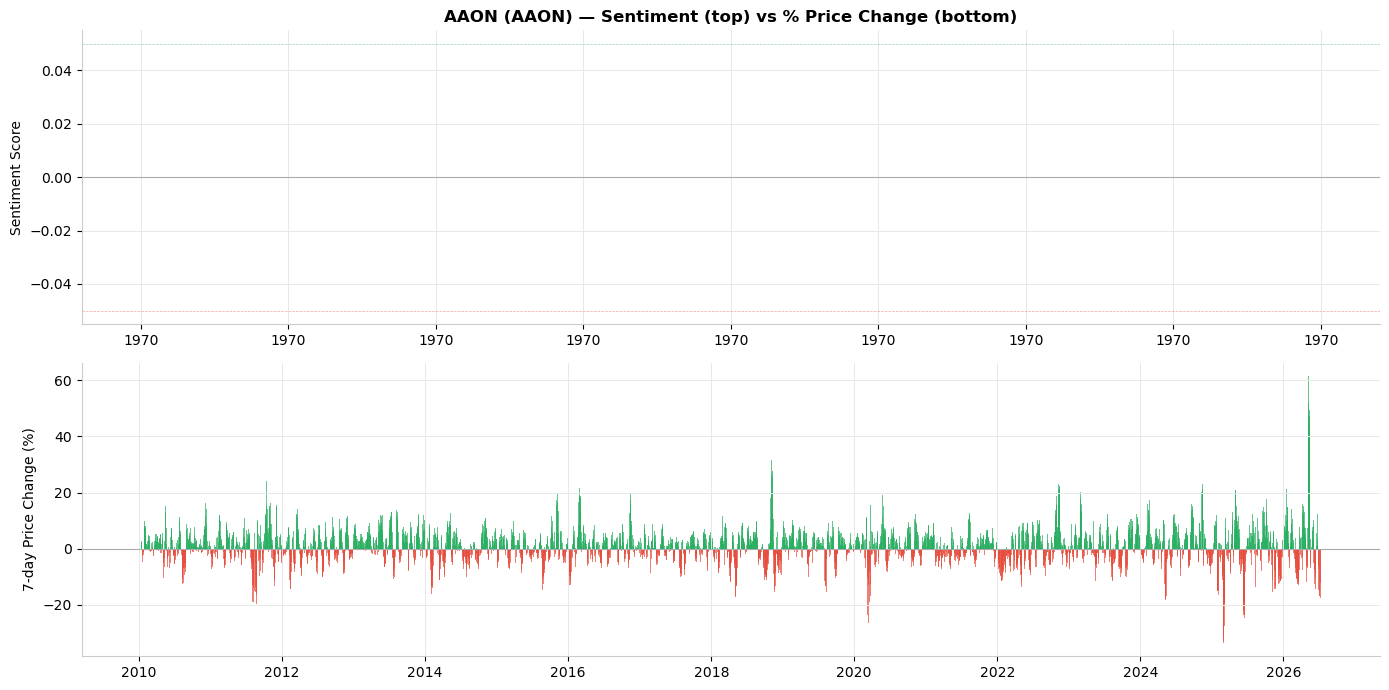

In [3]:
def plot_sentiment_vs_price(ticker, sig_col='norm_sentiment', window_days=None):
    sig = daily_signals[daily_signals['ticker']==ticker].copy().sort_values('date')
    try:
        price = load_csv(f'{STOCKS_PREFIX}/prices_{ticker}.csv', GITHUB_TOKEN)
        price['Date'] = pd.to_datetime(price['Date'])
        price['pct_change_7d'] = price['Close'].pct_change(7, fill_method=None) * 100
        price = price.set_index('Date').sort_index()
    except FileNotFoundError:
        print(f'{ticker}: no price data')
        return

    if window_days:
        cutoff = pd.Timestamp(ANALYSIS_END) - pd.Timedelta(days=window_days)
        sig   = sig[sig['date'] >= cutoff]
        price = price[price.index >= cutoff]

    name = ticker
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), facecolor='white',
                              sharex=False, gridspec_kw={'height_ratios': [1,1]})

    # Panel 1: Sentiment
    ax1 = axes[0]
    sent_vals = sig[sig_col].values
    dates_s   = sig['date'].values
    colors_s  = ['#27ae60' if v >= SENTIMENT_THRESHOLD
                  else ('#e74c3c' if v <= -SENTIMENT_THRESHOLD else '#bdc3c7')
                  for v in sent_vals]
    ax1.bar(dates_s, sent_vals, color=colors_s, alpha=0.8, width=2)
    ax1.axhline(0, color='#aaaaaa', linewidth=0.8)
    ax1.axhline( SENTIMENT_THRESHOLD, color='#27ae60', linewidth=0.5, linestyle='--', alpha=0.5)
    ax1.axhline(-SENTIMENT_THRESHOLD, color='#e74c3c', linewidth=0.5, linestyle='--', alpha=0.5)
    ax1.set_ylabel('Sentiment Score', fontsize=10)
    ax1.set_title(f'{name} ({ticker}) — Sentiment (top) vs % Price Change (bottom)', fontsize=12, fontweight='bold')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax1.set_facecolor('white')

    # Panel 2: 7-day % price change
    ax2 = axes[1]
    pct = price['pct_change_7d'].dropna()
    pos_mask = pct >= 0
    ax2.bar(pct.index[pos_mask],  pct.values[pos_mask],  color='#27ae60', alpha=0.7, width=5)
    ax2.bar(pct.index[~pos_mask], pct.values[~pos_mask], color='#e74c3c', alpha=0.7, width=5)
    ax2.axhline(0, color='#aaaaaa', linewidth=0.8)
    ax2.set_ylabel('7-day Price Change (%)', fontsize=10)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax2.set_facecolor('white')

    plt.tight_layout()
    plt.show()

# Plot for chart tickers + a few smaller/less-known ones
extra_tickers = [t for t in all_tickers if t not in CHART_TICKERS][:3]
for ticker in CHART_TICKERS + extra_tickers:
    plot_sentiment_vs_price(ticker, sig_col=sig_col)

---
## Chart 2: Mood-o-Meter

Green/red/gray bars for sentiment, blue line for stock price.

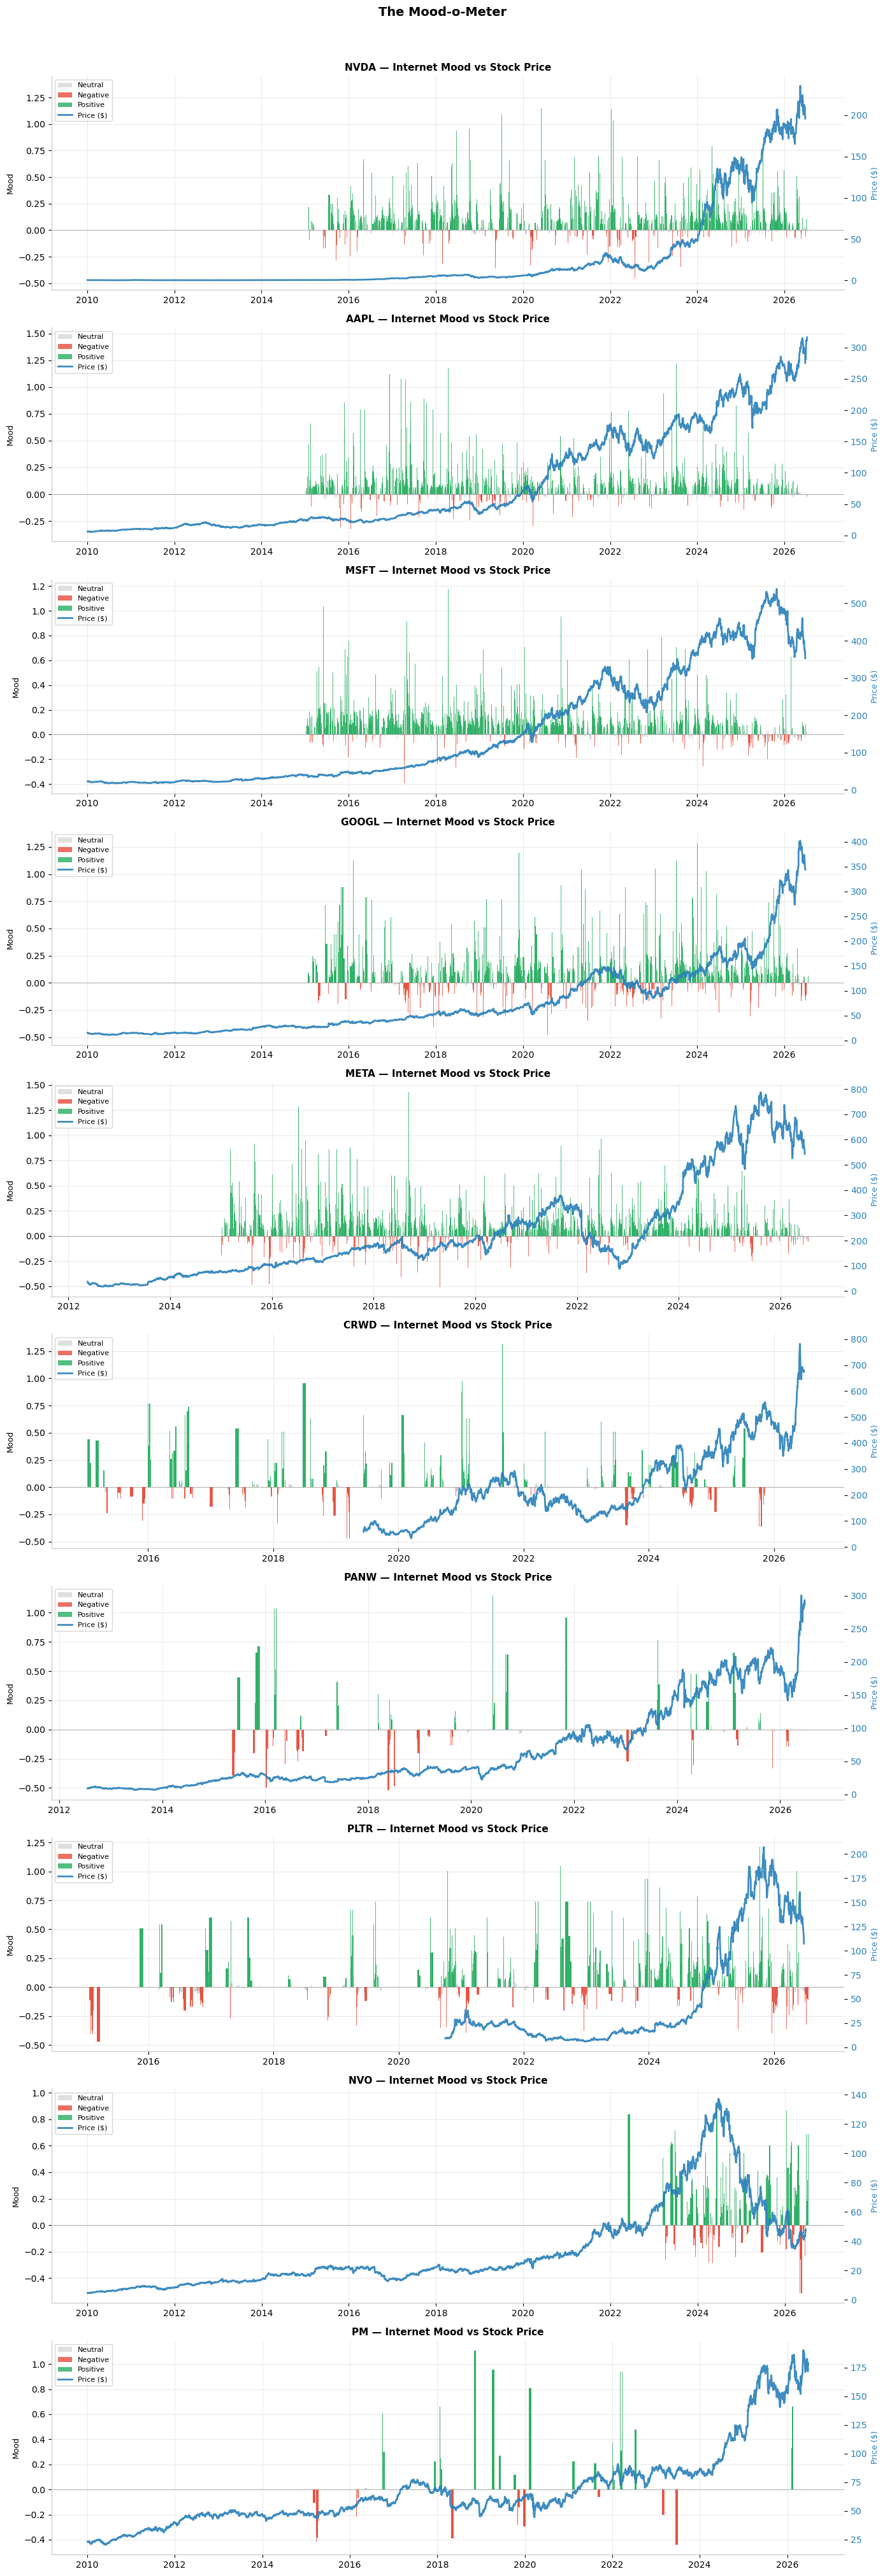

In [4]:
fig, axes = plt.subplots(len(CHART_TICKERS), 1,
                          figsize=(14, 4*len(CHART_TICKERS)), facecolor='white')
if len(CHART_TICKERS) == 1: axes = [axes]

for ax, ticker in zip(axes, CHART_TICKERS):
    sig = daily_signals[daily_signals['ticker']==ticker].copy()
    sig['date'] = pd.to_datetime(sig['date'])
    try:
        price = load_csv(f'{STOCKS_PREFIX}/prices_{ticker}.csv', GITHUB_TOKEN)
        price['Date'] = pd.to_datetime(price['Date'])
    except FileNotFoundError:
        continue

    pos = sig[sig[sig_col] >= SENTIMENT_THRESHOLD]
    neg = sig[sig[sig_col] <= -SENTIMENT_THRESHOLD]
    neu = sig[(sig[sig_col] > -SENTIMENT_THRESHOLD) & (sig[sig_col] < SENTIMENT_THRESHOLD)]

    ax.bar(neu['date'], neu[sig_col].fillna(0), color='#bdc3c7', alpha=0.5, width=2, label='Neutral', zorder=2)
    ax.bar(neg['date'], neg[sig_col].fillna(0), color='#e74c3c', alpha=0.8, width=2, label='Negative', zorder=3)
    ax.bar(pos['date'], pos[sig_col].fillna(0), color='#27ae60', alpha=0.8, width=2, label='Positive', zorder=3)
    ax.axhline(0, color='#aaaaaa', linewidth=0.7)
    ax.set_ylabel('Mood', fontsize=9)
    ax.set_facecolor('white')

    ax2 = ax.twinx()
    ax2.plot(price['Date'], price['Close'], color='#2980b9', linewidth=2, alpha=0.9, label='Price ($)', zorder=4)
    ax2.set_ylabel('Price ($)', fontsize=9, color='#2980b9')
    ax2.tick_params(axis='y', labelcolor='#2980b9')
    ax2.grid(False); ax2.set_facecolor('white')
    ax.set_title(f'{ticker} — Internet Mood vs Stock Price', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    l1,lb1 = ax.get_legend_handles_labels()
    l2,lb2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=8, facecolor='white')

fig.suptitle('The Mood-o-Meter', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Chart 3: Key Moment Zoom

Finds the biggest price moves first, then shows what sentiment preceded them.
Only shows moves where sentiment data existed beforehand.

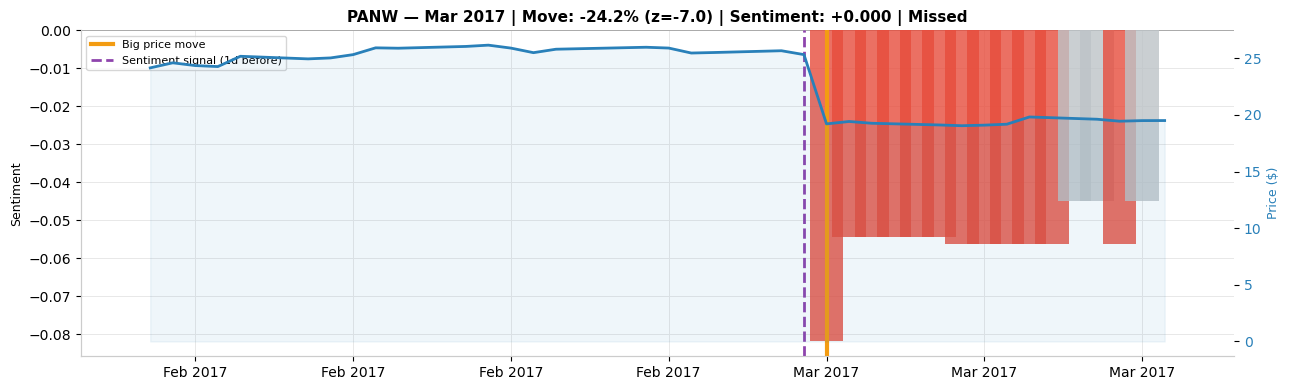

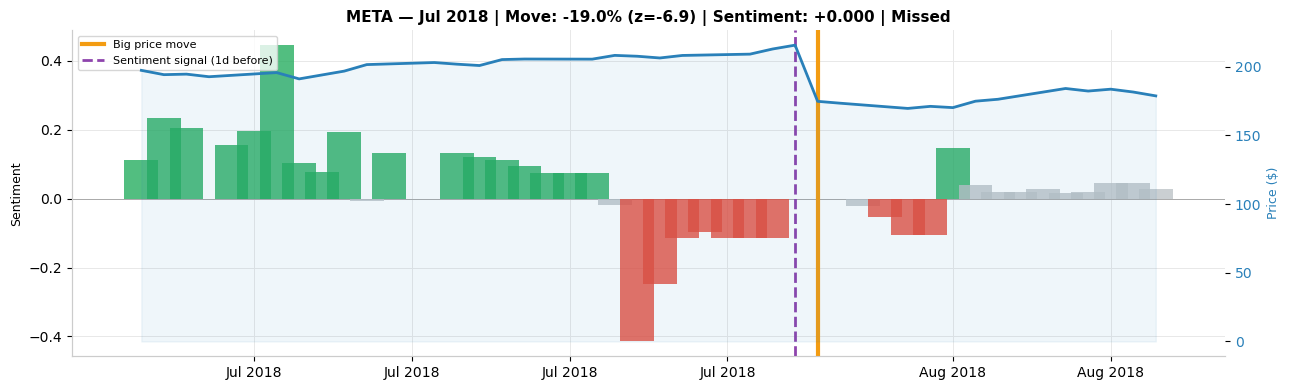

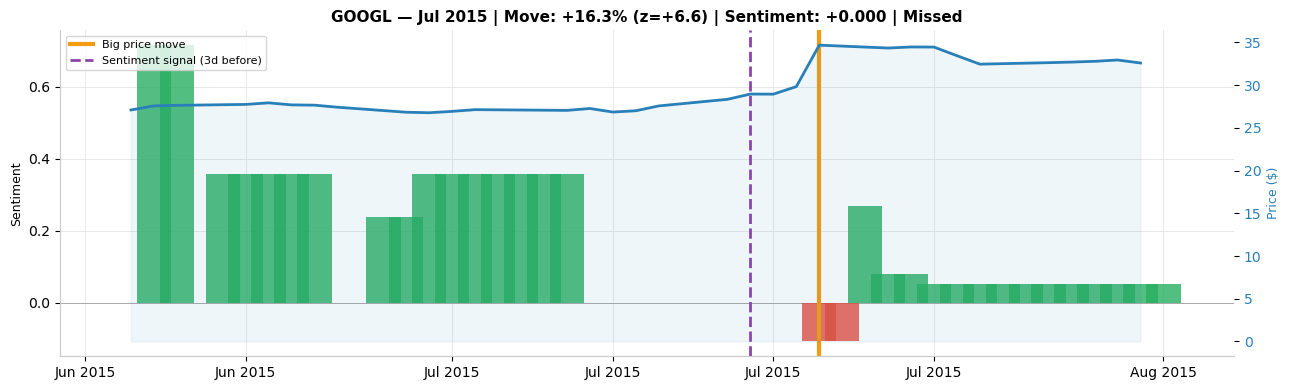

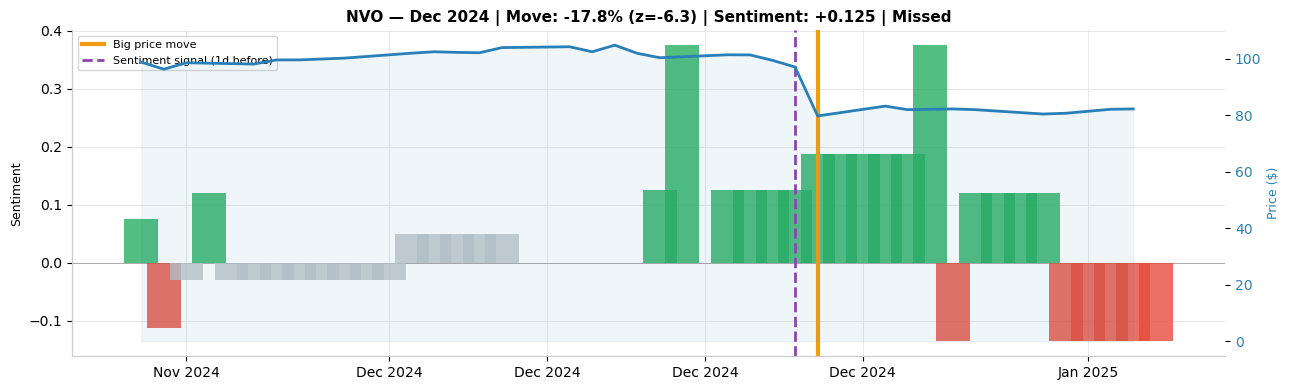

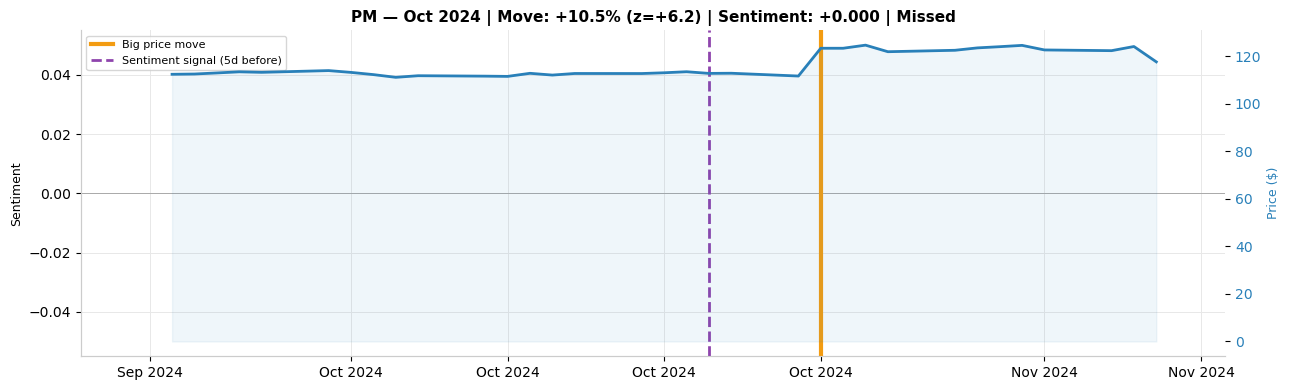

In [5]:
if df_key_moves.empty:
    print('No key moves data. Run B_correlation_engine.ipynb first.')
else:
    df_key_moves['move_date'] = pd.to_datetime(df_key_moves['move_date'])
    df_key_moves['sent_date'] = pd.to_datetime(df_key_moves['sent_date'])

    # Filter to CHART_TICKERS and largest moves
    top_moves = (
        df_key_moves[df_key_moves['ticker'].isin(CHART_TICKERS)]
        .sort_values('zscore', key=abs, ascending=False)
        .drop_duplicates(subset=['ticker'])
        .head(5)
    )

    for _, move in top_moves.iterrows():
        ticker    = move['ticker']
        move_date = move['move_date']
        win_start = move_date - pd.Timedelta(days=30)
        win_end   = move_date + pd.Timedelta(days=15)

        sig = daily_signals[(daily_signals['ticker']==ticker) &
                             (daily_signals['date'] >= win_start) &
                             (daily_signals['date'] <= win_end)].copy()
        try:
            price = load_csv(f'{STOCKS_PREFIX}/prices_{ticker}.csv', GITHUB_TOKEN)
            price['Date'] = pd.to_datetime(price['Date'])
            price = price[(price['Date'] >= win_start) & (price['Date'] <= win_end)].set_index('Date')
        except FileNotFoundError:
            continue

        fig, ax1 = plt.subplots(figsize=(13, 4), facecolor='white')
        ax2 = ax1.twinx()

        # Price
        ax2.fill_between(price.index, price['Close'], alpha=0.07, color='#2980b9')
        ax2.plot(price.index, price['Close'], color='#2980b9', linewidth=2, label='Price')
        ax2.set_ylabel('Price ($)', color='#2980b9', fontsize=9)
        ax2.tick_params(axis='y', labelcolor='#2980b9')
        ax2.grid(False); ax2.set_facecolor('white')

        # Sentiment bars
        sv = sig[sig_col].fillna(0)
        bar_colors = ['#27ae60' if v >= SENTIMENT_THRESHOLD
                       else ('#e74c3c' if v <= -SENTIMENT_THRESHOLD else '#bdc3c7')
                       for v in sv]
        ax1.bar(sig['date'], sv, color=bar_colors, alpha=0.8, width=1.5, zorder=3)
        ax1.axhline(0, color='#aaaaaa', linewidth=0.7)
        ax1.set_ylabel('Sentiment', fontsize=9)
        ax1.set_facecolor('white')

        # Mark the big move
        ax1.axvline(move_date, color='#f39c12', linewidth=3, zorder=5, label='Big price move')
        ax1.axvline(move['sent_date'], color='#8e44ad', linewidth=2,
                    linestyle='--', zorder=4, label=f'Sentiment signal ({move["days_before"]}d before)')

        ret_pct = move['return_pct']
        color   = '#27ae60' if ret_pct > 0 else '#e74c3c'
        correct = 'Predicted' if move['predicted'] else 'Missed'
        ax1.set_title(
            f'{ticker} — {move_date.strftime("%b %Y")} | '
            f'Move: {ret_pct:+.1f}% (z={move["zscore"]:+.1f}) | '
            f'Sentiment: {move["sentiment"]:+.3f} | {correct}',
            fontsize=11, fontweight='bold'
        )
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax1.legend(fontsize=8, facecolor='white', loc='upper left')
        plt.tight_layout()
        plt.show()

---
## Chart 4: Four Quadrant — True/False Positive/Negative

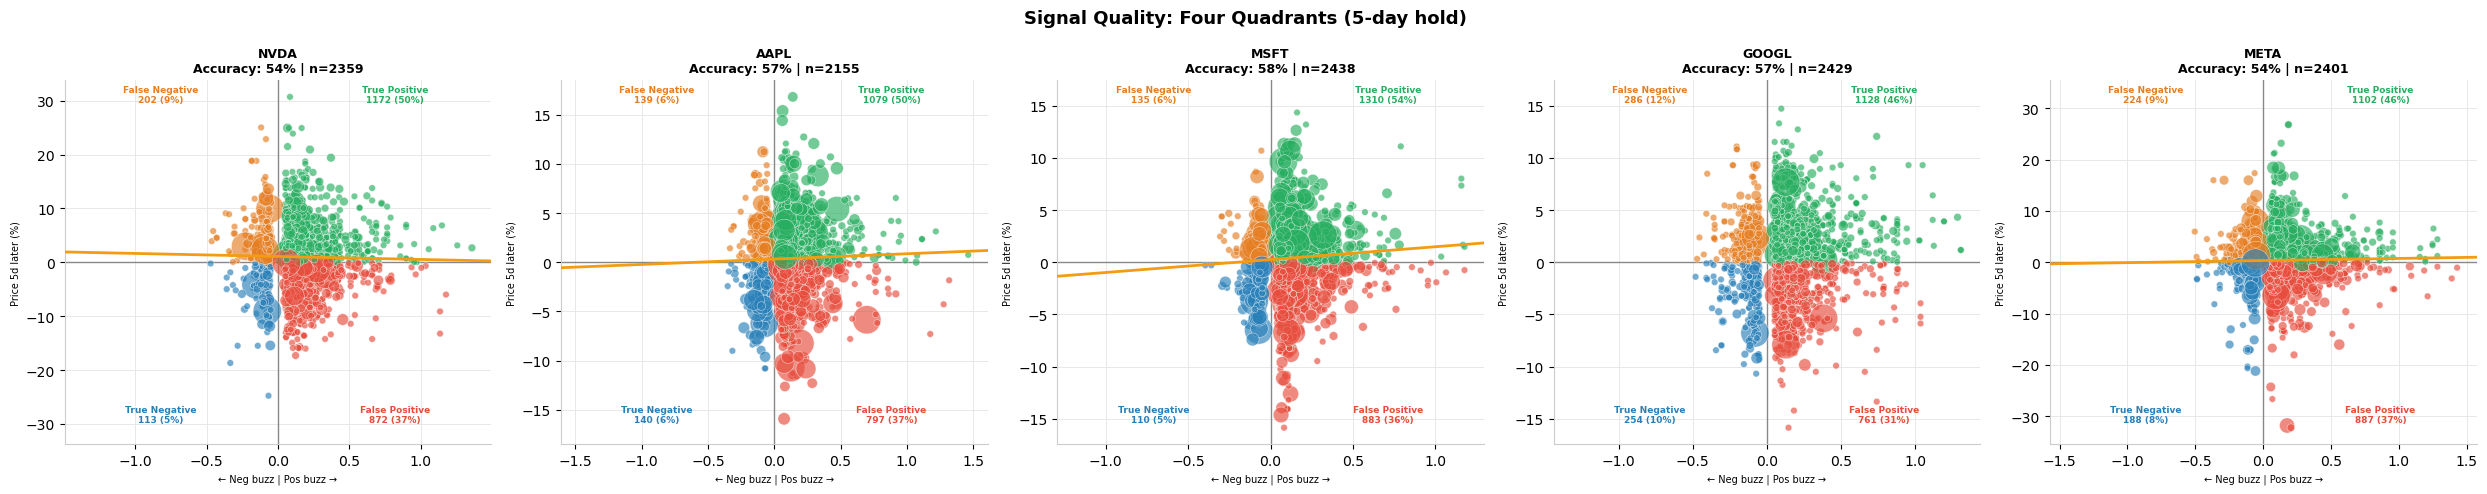

ticker   TP  FP  TN  FN  accuracy
  NVDA 1172 872 113 202     0.545
  AAPL 1079 797 140 139     0.566
  MSFT 1310 883 110 135     0.582
 GOOGL 1128 761 254 286     0.569
  META 1102 887 188 224     0.537


In [6]:
HOLD_DAYS_Q = 5
ncols = min(5, len(CHART_TICKERS))
fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 5), facecolor='white')
if ncols == 1: axes = [axes]

summary_rows = []
for ax, ticker in zip(axes, CHART_TICKERS):
    sig = daily_signals[daily_signals['ticker']==ticker].copy().sort_values('date')
    try:
        price = load_csv(f'{STOCKS_PREFIX}/prices_{ticker}.csv', GITHUB_TOKEN)
        price['Date'] = pd.to_datetime(price['Date'])
        price = price.set_index('Date').sort_index()
        price['daily_return'] = price['Close'].pct_change(fill_method=None)
    except FileNotFoundError:
        ax.set_visible(False); continue

    rows = []
    for _, srow in sig.iterrows():
        sv = srow.get(sig_col, np.nan)
        if pd.isna(sv) or abs(sv) < SENTIMENT_THRESHOLD: continue
        future = price.index[price.index > srow['date']]
        if len(future) < HOLD_DAYS_Q: continue
        ep = price.loc[future[0], 'Close']
        xp = price.loc[future[HOLD_DAYS_Q-1], 'Close']
        ret = (xp - ep) / ep * 100
        if sv >= SENTIMENT_THRESHOLD and ret > 0:   q,c = 'TP','#27ae60'
        elif sv >= SENTIMENT_THRESHOLD and ret <= 0: q,c = 'FP','#e74c3c'
        elif sv <= -SENTIMENT_THRESHOLD and ret < 0: q,c = 'TN','#2980b9'
        else:                                         q,c = 'FN','#e67e22'
        rows.append({'sent':sv,'ret':ret,'q':q,'c':c,'stories':srow.get('story_count',1)})

    if not rows: ax.set_visible(False); continue
    df_plot = pd.DataFrame(rows)
    ax.scatter(df_plot['sent'], df_plot['ret'], c=df_plot['c'], alpha=0.65,
               s=df_plot['stories'].clip(1,50)*8+15, edgecolors='white', linewidths=0.4, zorder=3)
    ax.axhline(0, color='#888888', linewidth=1, zorder=2)
    ax.axvline(0, color='#888888', linewidth=1, zorder=2)
    xmax = df_plot['sent'].abs().max()*1.1; ymax = df_plot['ret'].abs().max()*1.1
    ax.set_xlim(-xmax,xmax); ax.set_ylim(-ymax,ymax)
    counts = df_plot['q'].value_counts()
    tp,fp,tn,fn = counts.get('TP',0),counts.get('FP',0),counts.get('TN',0),counts.get('FN',0)
    total = len(df_plot)
    ax.text( xmax*.55, ymax*.88, f'True Positive\n{tp} ({tp/total:.0%})',   fontsize=6.5, color='#27ae60', ha='center', fontweight='bold')
    ax.text(-xmax*.55, ymax*.88, f'False Negative\n{fn} ({fn/total:.0%})',  fontsize=6.5, color='#e67e22', ha='center', fontweight='bold')
    ax.text( xmax*.55,-ymax*.88, f'False Positive\n{fp} ({fp/total:.0%})',  fontsize=6.5, color='#e74c3c', ha='center', fontweight='bold')
    ax.text(-xmax*.55,-ymax*.88, f'True Negative\n{tn} ({tn/total:.0%})',   fontsize=6.5, color='#2980b9', ha='center', fontweight='bold')
    if len(df_plot) > 5:
        z = np.polyfit(df_plot['sent'],df_plot['ret'],1)
        xs = np.linspace(-xmax,xmax,100)
        ax.plot(xs, np.poly1d(z)(xs), color='#f39c12', linewidth=2, zorder=4)
    acc = (tp+tn)/total
    ax.set_xlabel('← Neg buzz | Pos buzz →', fontsize=7)
    ax.set_ylabel(f'Price {HOLD_DAYS_Q}d later (%)', fontsize=7)
    ax.set_title(f'{ticker}\nAccuracy: {acc:.0%} | n={total}', fontsize=9, fontweight='bold')
    ax.set_facecolor('white')
    summary_rows.append({'ticker':ticker,'TP':tp,'FP':fp,'TN':tn,'FN':fn,'accuracy':round(acc,3)})

for ax in axes[len(CHART_TICKERS):]: ax.set_visible(False)
fig.suptitle(f'Signal Quality: Four Quadrants ({HOLD_DAYS_Q}-day hold)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
if summary_rows:
    print(pd.DataFrame(summary_rows).to_string(index=False))

---
## Chart 5: Correlation Bar Chart

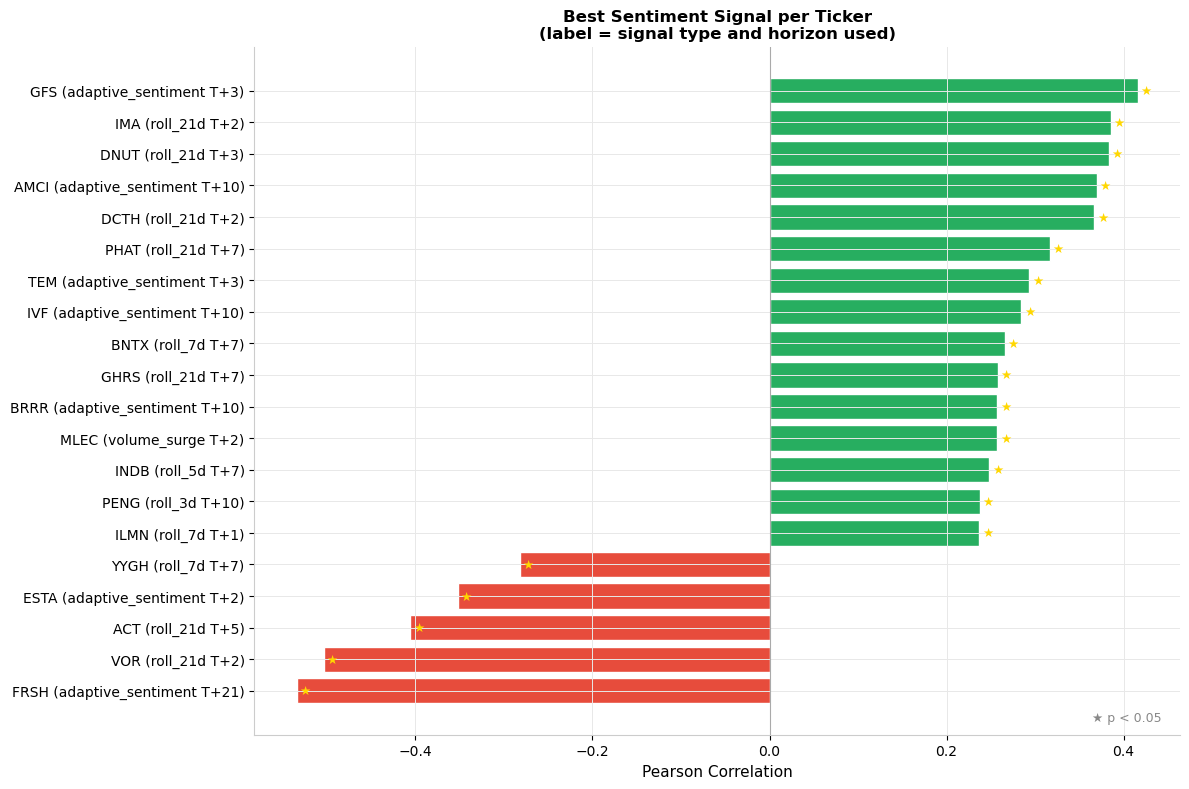

In [7]:
if df_corr.empty:
    print('No correlation data. Run B_correlation_engine.ipynb first.')
else:
    top15 = best_per_ticker.nlargest(15,'corr',keep='all')
    bot5  = best_per_ticker.nsmallest(5,'corr',keep='all')
    plot_df = pd.concat([top15,bot5]).drop_duplicates('ticker').sort_values('corr')

    fig, ax = plt.subplots(figsize=(12,8), facecolor='white')
    colors = ['#e74c3c' if v<0 else '#27ae60' for v in plot_df['corr']]
    bars = ax.barh(
        plot_df['ticker']+' ('+plot_df['signal']+' T+'+plot_df['horizon'].astype(str)+')',
        plot_df['corr'], color=colors, edgecolor='white'
    )
    ax.axvline(0, color='#aaaaaa', linewidth=0.8)
    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        if row['significant']:
            ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                    '★', va='center', fontsize=9, color='gold')
    ax.text(0.98,0.02,'★ p < 0.05', transform=ax.transAxes, ha='right', fontsize=9, color='#888888')
    ax.set_xlabel('Pearson Correlation', fontsize=11)
    ax.set_title('Best Sentiment Signal per Ticker\n(label = signal type and horizon used)',
                 fontsize=12, fontweight='bold')
    ax.set_facecolor('white')
    plt.tight_layout()
    plt.show()

---
## Chart 6: Source Contribution

Which data source (HN, Reddit, GDELT, StockTwits) contributes most to each ticker's signal?

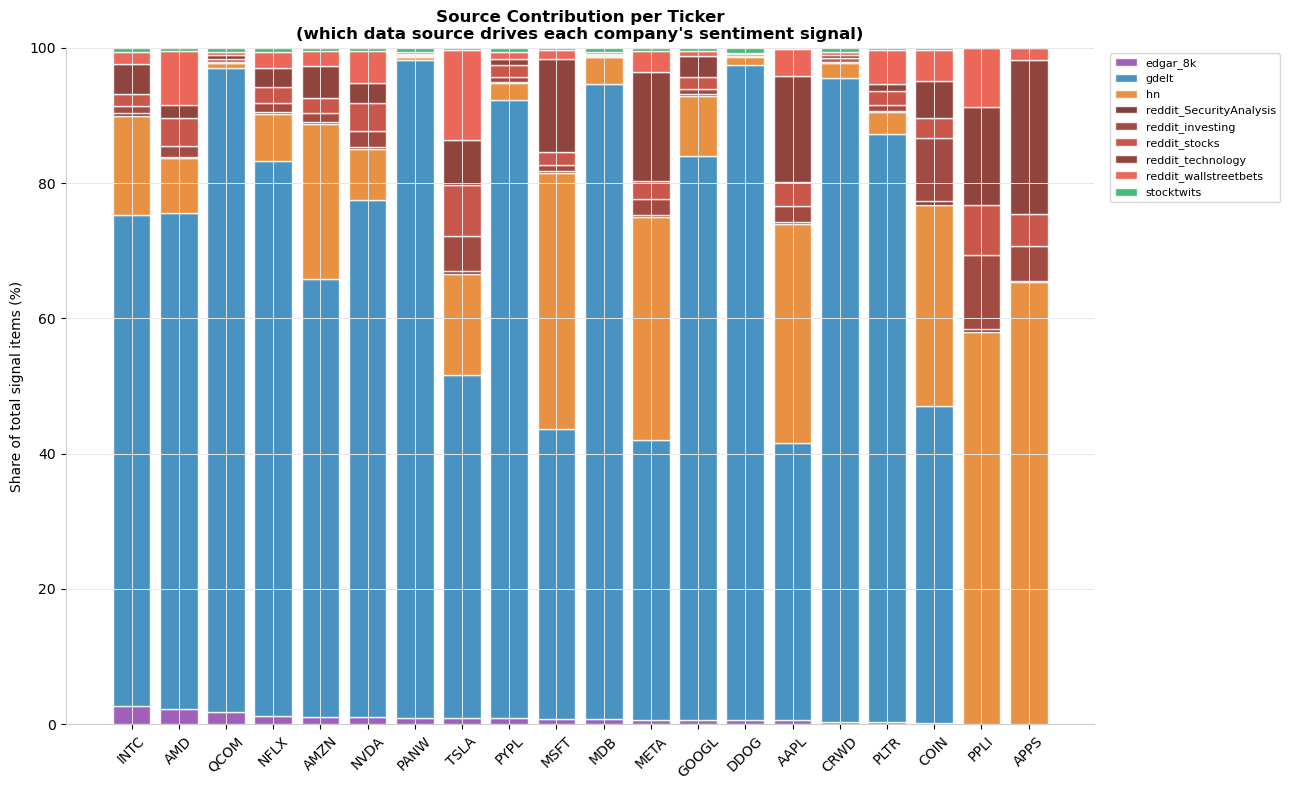


Dominant source per ticker:
ticker dominant_source
  INTC           gdelt
   AMD           gdelt
  QCOM           gdelt
  NFLX           gdelt
  AMZN           gdelt
  NVDA           gdelt
  PANW           gdelt
  TSLA           gdelt
  PYPL           gdelt
  MSFT           gdelt
   MDB           gdelt
  META           gdelt
 GOOGL           gdelt
  DDOG           gdelt
  AAPL           gdelt
  CRWD           gdelt
  PLTR           gdelt
  COIN           gdelt
  PPLI              hn
  APPS              hn


In [8]:
if source_attr.empty:
    print('No source attribution data. Run B_correlation_engine.ipynb first.')
else:
    # Pivot: tickers × sources, values = item count
    top20_by_items = (
        source_attr.groupby('ticker')['item_count'].sum()
        .sort_values(ascending=False).head(20).index.tolist()
    )
    pivot = source_attr[source_attr['ticker'].isin(top20_by_items)].pivot_table(
        index='ticker', columns='source', values='item_count', fill_value=0
    )
    pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100  # normalize to %
    pivot = pivot.sort_values(pivot.columns[0], ascending=False)

    src_colors = {
        'hn':'#e67e22', 'reddit_wallstreetbets':'#e74c3c',
        'reddit_stocks':'#c0392b', 'reddit_investing':'#922b21',
        'reddit_technology':'#7b241c', 'reddit_SecurityAnalysis':'#641e16',
        'gdelt':'#2980b9', 'stocktwits':'#27ae60', 'edgar_8k':'#8e44ad',
    }
    fig, ax = plt.subplots(figsize=(13, 8), facecolor='white')
    bottom = np.zeros(len(pivot))
    for col in pivot.columns:
        color = src_colors.get(col, '#888888')
        ax.bar(pivot.index, pivot[col], bottom=bottom, label=col,
               color=color, edgecolor='white', alpha=0.85)
        bottom += pivot[col].values
    ax.set_ylabel('Share of total signal items (%)', fontsize=10)
    ax.set_title('Source Contribution per Ticker\n(which data source drives each company\'s sentiment signal)',
                 fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=45)
    ax.legend(fontsize=8, facecolor='white', bbox_to_anchor=(1.01,1), loc='upper left')
    ax.set_facecolor('white')
    plt.tight_layout()
    plt.show()
    print('\nDominant source per ticker:')
    print(pivot.idxmax(axis=1).rename('dominant_source').reset_index().to_string(index=False))

---
## Chart 7: Buzz Leaderboard

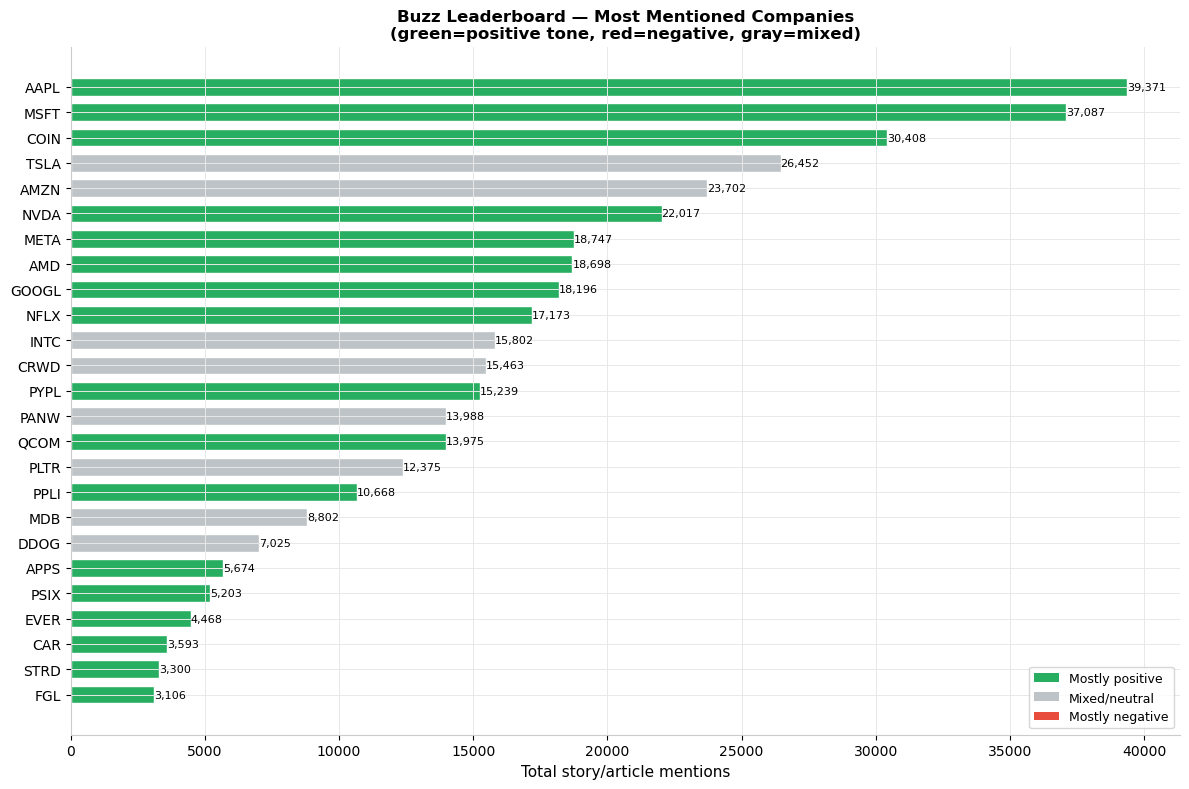

In [9]:
buzz_totals = (
    daily_signals[daily_signals['norm_sentiment'].notna()]
    .groupby('ticker')
    .agg(total_stories=('story_count','sum'), avg_sentiment=('norm_sentiment','mean'))
    .reset_index().sort_values('total_stories', ascending=False).head(25)
)
bar_colors = ['#27ae60' if s>0.05 else ('#e74c3c' if s<-0.05 else '#bdc3c7')
              for s in buzz_totals['avg_sentiment']]
fig, ax = plt.subplots(figsize=(12,8), facecolor='white')
bars = ax.barh(buzz_totals['ticker'][::-1], buzz_totals['total_stories'][::-1],
               color=bar_colors[::-1], edgecolor='white', height=0.7)
for bar, val in zip(bars, buzz_totals['total_stories'][::-1]):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
ax.set_xlabel('Total story/article mentions', fontsize=11)
ax.set_title('Buzz Leaderboard — Most Mentioned Companies\n(green=positive tone, red=negative, gray=mixed)',
             fontsize=12, fontweight='bold')
legend_elements = [
    mpatches.Patch(facecolor='#27ae60', label='Mostly positive'),
    mpatches.Patch(facecolor='#bdc3c7', label='Mixed/neutral'),
    mpatches.Patch(facecolor='#e74c3c', label='Mostly negative'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, facecolor='white')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

---
## Chart 8 & 9: Portfolio Growth + Strategy Good/Bad Periods

All strategies compounding from the same start date, benchmarked vs S&P 500.
Gradient shading shows when each strategy was winning or losing.

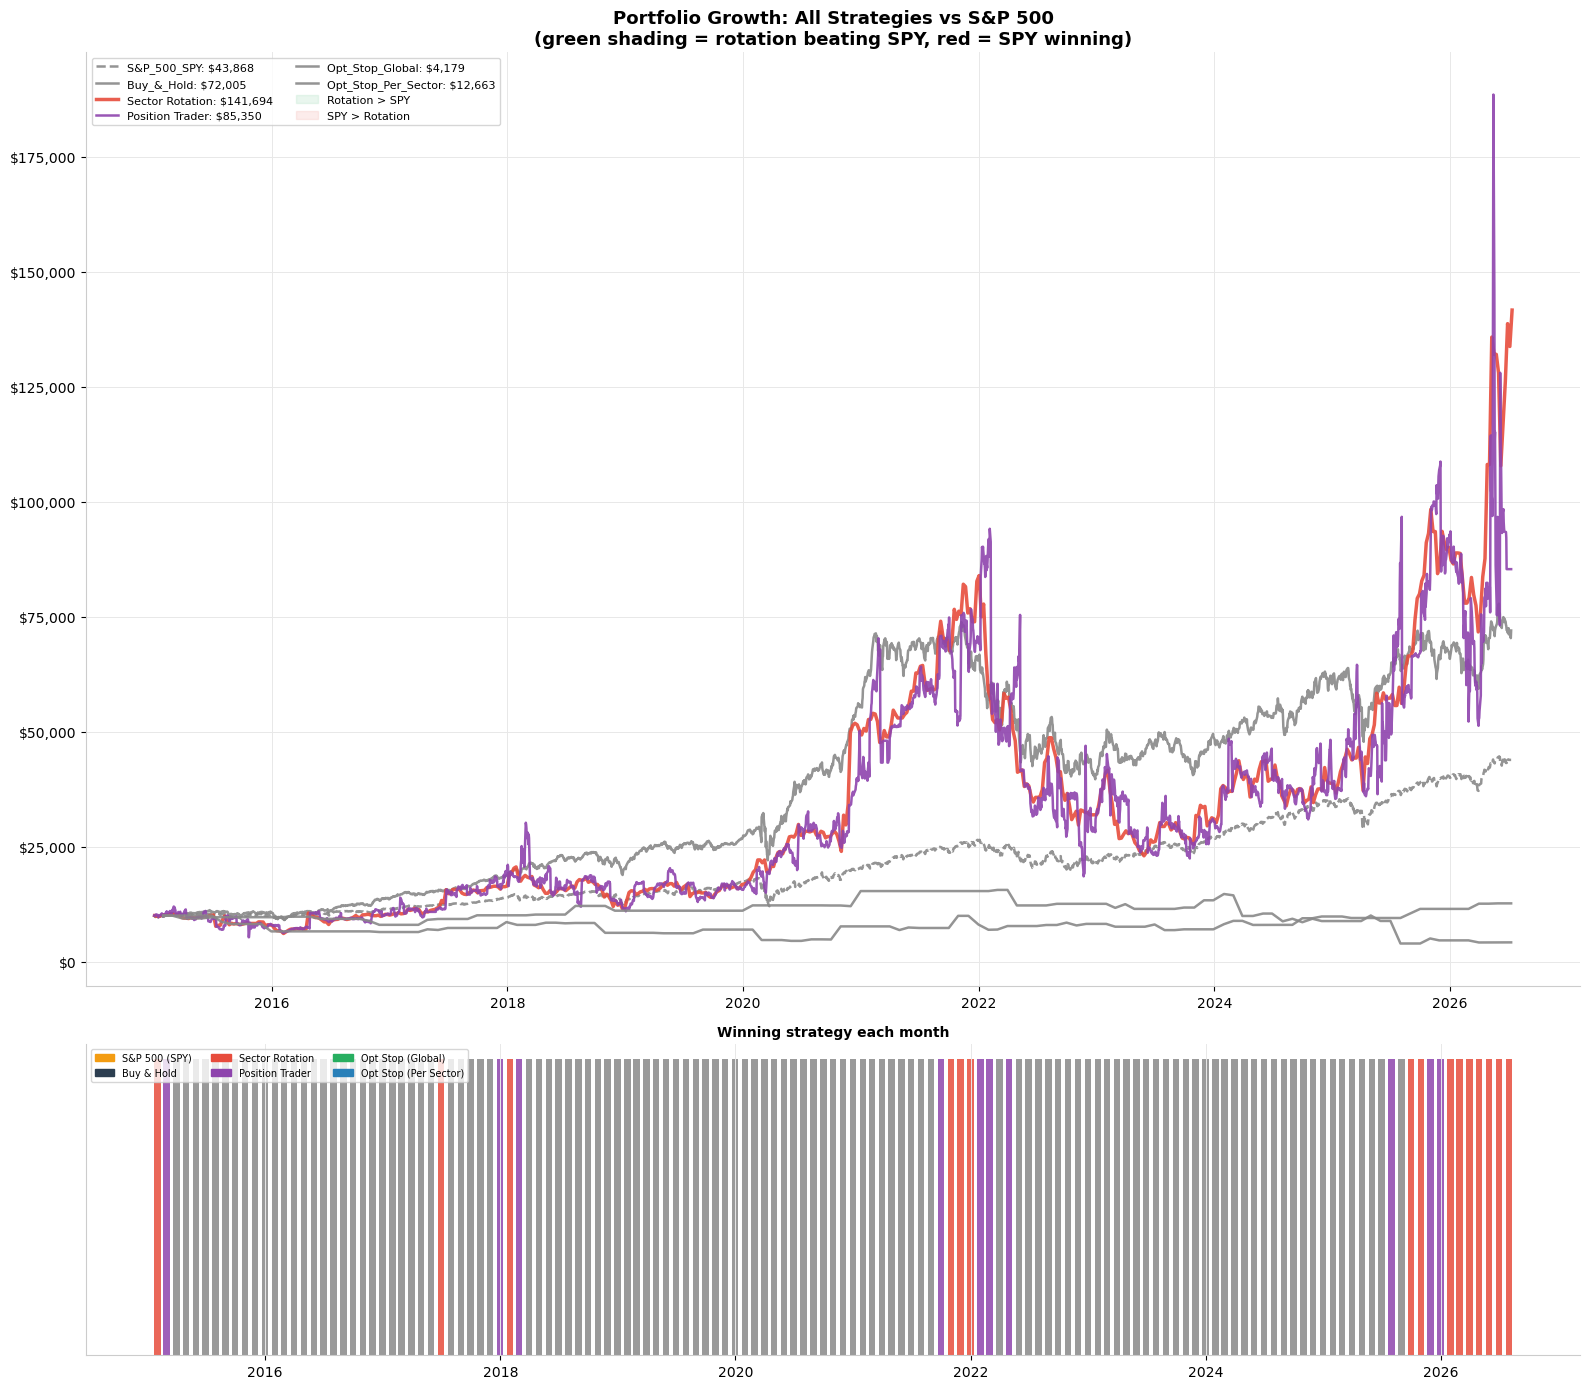

In [10]:
if df_equity.empty:
    print('No equity data. Run C_strategy_engine.ipynb first.')
else:
    strat_colors = {
        'SP_500_SPY_'      : '#f39c12',
        'Buy__Hold'        : '#2c3e50',
        'Sector_Rotation'  : '#e74c3c',
        'Position_Trader'  : '#8e44ad',
        'Opt_Stop_Global_' : '#27ae60',
        'Opt_Stop_Per_Sector_': '#2980b9',
    }
    strat_labels = {
        'SP_500_SPY_'      : 'S&P 500 (SPY)',
        'Buy__Hold'        : 'Buy & Hold',
        'Sector_Rotation'  : 'Sector Rotation',
        'Position_Trader'  : 'Position Trader',
        'Opt_Stop_Global_' : 'Opt Stop (Global)',
        'Opt_Stop_Per_Sector_': 'Opt Stop (Per Sector)',
    }

    fig, axes = plt.subplots(2,1, figsize=(16,14), facecolor='white',
                              gridspec_kw={'height_ratios':[3,1]})
    ax = axes[0]

    spy_col = [c for c in df_equity.columns if 'SPY' in c or 'spy' in c.lower()]
    spy_series = df_equity.set_index('date')[spy_col[0]] if spy_col else None

    for col in df_equity.columns:
        if col == 'date': continue
        series = df_equity.set_index('date')[col].dropna()
        color  = strat_colors.get(col, '#888888')
        label  = strat_labels.get(col, col)
        ls     = '--' if 'SPY' in col else '-'
        lw     = 2.5 if col in ('Sector_Rotation','Buy__Hold','SP_500_SPY_') else 1.8
        final  = series.iloc[-1] if not series.empty else 0
        ax.plot(series.index, series.values, color=color, linestyle=ls,
                linewidth=lw, label=f'{label}: ${final:,.0f}', alpha=0.9)

    # Gradient: green when rotation > SPY, red otherwise
    rot_col = [c for c in df_equity.columns if 'Rotation' in c]
    if rot_col and spy_col:
        rot_s = df_equity.set_index('date')[rot_col[0]].dropna()
        spy_s = spy_series.reindex(rot_s.index).interpolate('time')
        ax.fill_between(rot_s.index, spy_s, rot_s,
                        where=rot_s >= spy_s, color='#a9dfbf', alpha=0.25, label='Rotation > SPY')
        ax.fill_between(rot_s.index, spy_s, rot_s,
                        where=rot_s <  spy_s, color='#f5b7b1', alpha=0.25, label='SPY > Rotation')

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.set_title('Portfolio Growth: All Strategies vs S&P 500\n(green shading = rotation beating SPY, red = SPY winning)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, facecolor='white', loc='upper left', ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_facecolor('white')

    # Bottom panel: winning strategy each month
    ax2 = axes[1]
    monthly = df_equity.set_index('date').resample('ME').last().dropna(how='all')
    if not monthly.empty:
        winner_each = monthly.idxmax(axis=1)
        for month, winner in winner_each.items():
            c = strat_colors.get(winner,'#888888')
            ax2.bar(month, 1, width=20, color=c, alpha=0.85)
        ax2.set_yticks([])
        ax2.set_title('Winning strategy each month', fontsize=10, fontweight='bold')
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        legend_p = [mpatches.Patch(color=v, label=strat_labels.get(k,k))
                    for k,v in strat_colors.items()]
        ax2.legend(handles=legend_p, fontsize=7, loc='upper left', ncol=3, facecolor='white')
        ax2.set_facecolor('white')

    plt.tight_layout()
    plt.show()

---
## Chart 10: Strategy Selector Heatmap

Age × price stage grid showing win rate. Green = follow buzz, red = just hold.

Building lifecycle features for heatmap ...


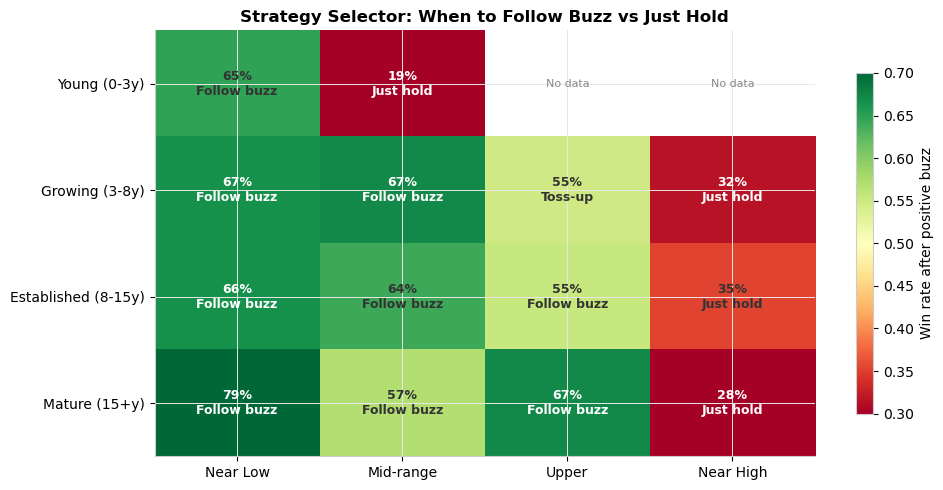

In [11]:
print('Building lifecycle features for heatmap ...')

lifecycle_rows = []
for ticker in CHART_TICKERS:
    sig = daily_signals[daily_signals['ticker']==ticker].copy()
    try:
        price = load_csv(f'{STOCKS_PREFIX}/prices_{ticker}.csv', GITHUB_TOKEN)
        price['Date'] = pd.to_datetime(price['Date'])
        price = price.set_index('Date').sort_index()
    except FileNotFoundError: continue

    first_date    = price.index.min()
    all_time_high = price['Close'].max()
    all_time_low  = price['Close'].min()
    price_range   = all_time_high - all_time_low

    for _, srow in sig.iterrows():
        date = pd.Timestamp(srow['date'])
        sv   = srow.get(sig_col, np.nan)
        if pd.isna(sv): continue
        future = price.index[price.index > date]
        if len(future) < 21: continue
        ret_t21 = (price.loc[future[20],'Close'] - price.loc[future[0],'Close']) / price.loc[future[0],'Close'] * 100
        past = price.index[price.index <= date]
        if len(past) == 0: continue
        current_close = price.loc[past[-1],'Close']
        age_years = (date - first_date).days / 365.25
        price_pct = (current_close - all_time_low) / price_range if price_range > 0 else 0.5
        if age_years < 3:    age_bucket = 'Young (0-3y)'
        elif age_years < 8:  age_bucket = 'Growing (3-8y)'
        elif age_years < 15: age_bucket = 'Established (8-15y)'
        else:                age_bucket = 'Mature (15+y)'
        if price_pct < 0.25:   price_stage = 'Near Low'
        elif price_pct < 0.60: price_stage = 'Mid-range'
        elif price_pct < 0.85: price_stage = 'Upper'
        else:                  price_stage = 'Near High'
        lifecycle_rows.append({'ticker':ticker,'sentiment':sv,'ret_t21':ret_t21,
                               'age_bucket':age_bucket,'price_stage':price_stage})

df_lc = pd.DataFrame(lifecycle_rows)
age_order   = ['Young (0-3y)','Growing (3-8y)','Established (8-15y)','Mature (15+y)']
stage_order = ['Near Low','Mid-range','Upper','Near High']

pivot_data = (
    df_lc.assign(pos_buzz=df_lc['sentiment'] >= SENTIMENT_THRESHOLD)
    .groupby(['age_bucket','price_stage'])
    .apply(lambda g: (g.loc[g['pos_buzz'],'ret_t21'] > 0).mean() if g['pos_buzz'].any() else np.nan, include_groups=False)
    .reset_index()
)
pivot_data.columns = ['age_bucket','price_stage','win_rate']
pivot_table = pivot_data.pivot(index='age_bucket', columns='price_stage', values='win_rate')
pivot_table = pivot_table.reindex(index=age_order, columns=stage_order)

fig, ax = plt.subplots(figsize=(10,5), facecolor='white')
im = ax.imshow(pivot_table.values, cmap='RdYlGn', vmin=0.3, vmax=0.7, aspect='auto')
ax.set_xticks(range(len(stage_order))); ax.set_xticklabels(stage_order, fontsize=10)
ax.set_yticks(range(len(age_order)));   ax.set_yticklabels(age_order, fontsize=10)
for i in range(len(age_order)):
    for j in range(len(stage_order)):
        val = pivot_table.values[i,j]
        if not np.isnan(val):
            verdict = 'Follow buzz' if val>=0.55 else ('Just hold' if val<0.45 else 'Toss-up')
            ax.text(j,i,f'{val*100:.0f}%\n{verdict}',ha='center',va='center',
                    fontsize=9,fontweight='bold',
                    color='white' if (val>0.65 or val<0.35) else '#333333')
        else:
            ax.text(j,i,'No data',ha='center',va='center',fontsize=8,color='#888888')
plt.colorbar(im, ax=ax, label='Win rate after positive buzz', shrink=0.8)
ax.set_title('Strategy Selector: When to Follow Buzz vs Just Hold',
             fontsize=12, fontweight='bold')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

---
## Chart 11: Absolute vs Relative Sentiment

Fixed version: shows three panels — price, absolute sentiment, and z-score of sentiment vs its own 90-day baseline.
The relative chart highlights when buzz is *unusually* positive or negative for that specific company.

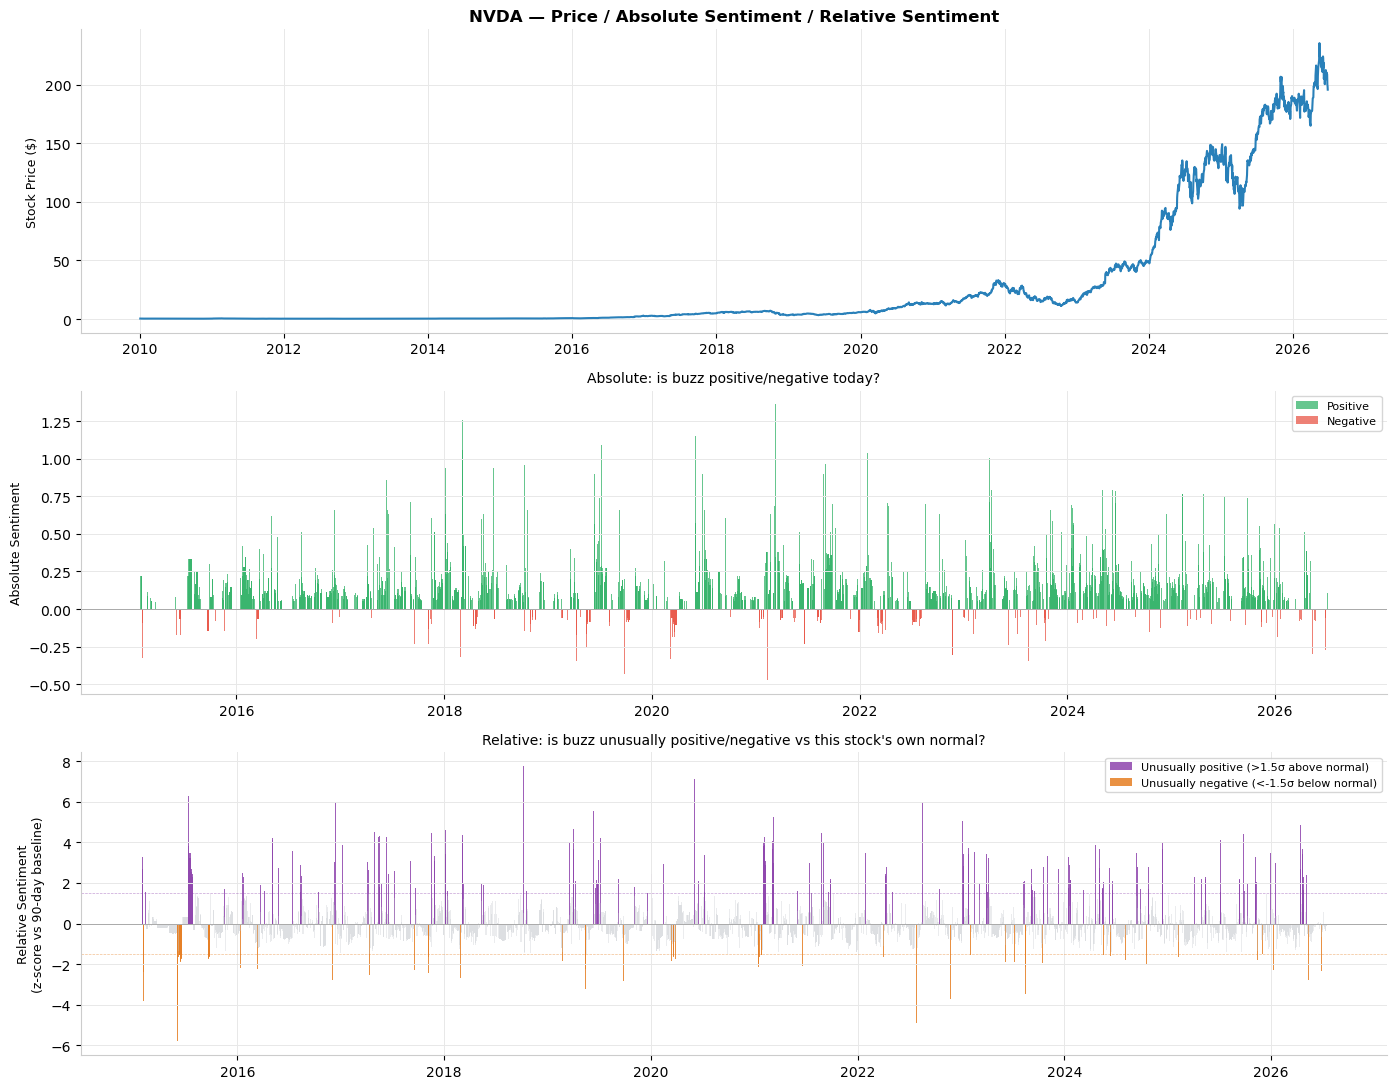

NVDA: relative sentiment uses 90-day rolling baseline
  Purple spikes = unusually positive vs normal for this stock
  Orange spikes = unusually negative vs normal for this stock


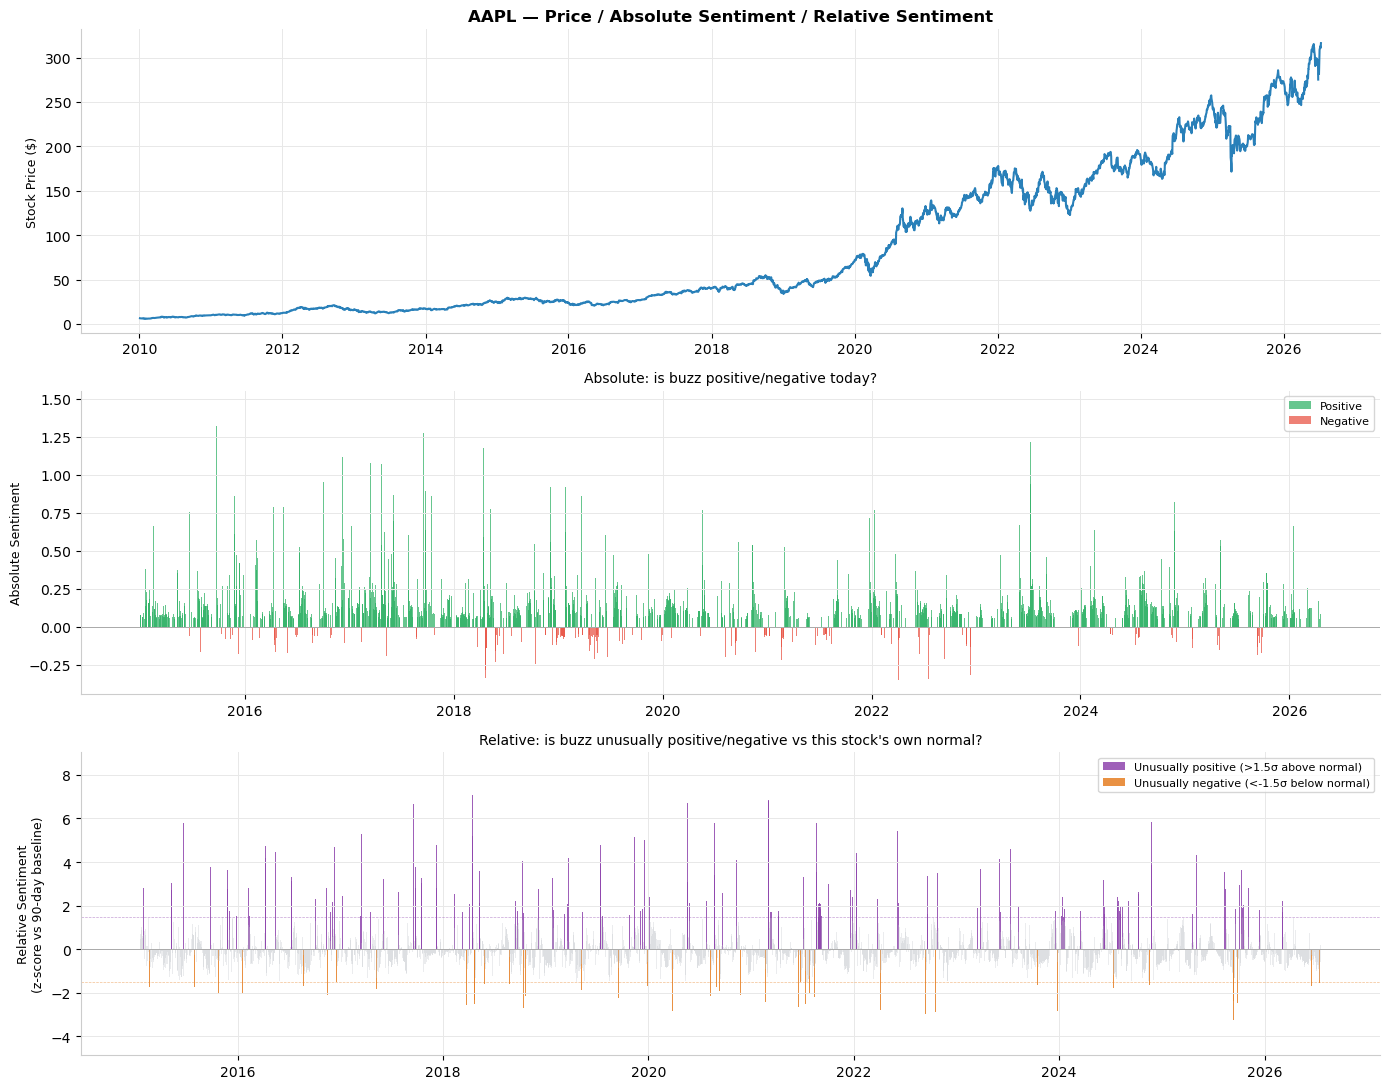

AAPL: relative sentiment uses 90-day rolling baseline
  Purple spikes = unusually positive vs normal for this stock
  Orange spikes = unusually negative vs normal for this stock


In [12]:
for ticker in CHART_TICKERS[:2]:  # top 2 to keep runtime reasonable
    sig = daily_signals[daily_signals['ticker']==ticker].copy().sort_values('date')
    try:
        price = load_csv(f'{STOCKS_PREFIX}/prices_{ticker}.csv', GITHUB_TOKEN)
        price['Date'] = pd.to_datetime(price['Date'])
        price = price.set_index('Date').sort_index()
    except FileNotFoundError: continue

    # Compute relative sentiment: z-score vs 90-day rolling baseline
    sig['baseline_mean'] = sig[sig_col].rolling(90, min_periods=20).mean()
    sig['baseline_std']  = sig[sig_col].rolling(90, min_periods=20).std()
    sig['relative_sent'] = ((sig[sig_col] - sig['baseline_mean'])
                             / (sig['baseline_std'] + 0.001))

    fig, axes = plt.subplots(3,1, figsize=(14,11), facecolor='white')

    # Panel 1: Price
    axes[0].plot(price.index, price['Close'], color='#2980b9', linewidth=1.5)
    axes[0].set_ylabel('Stock Price ($)', fontsize=9)
    axes[0].set_title(f'{ticker} — Price / Absolute Sentiment / Relative Sentiment',
                      fontsize=12, fontweight='bold')
    axes[0].set_facecolor('white')

    # Panel 2: Absolute sentiment
    pos_a = sig[sig[sig_col] >= SENTIMENT_THRESHOLD]
    neg_a = sig[sig[sig_col] <= -SENTIMENT_THRESHOLD]
    axes[1].bar(pos_a['date'], pos_a[sig_col], color='#27ae60', alpha=0.7, width=2, label='Positive')
    axes[1].bar(neg_a['date'], neg_a[sig_col], color='#e74c3c', alpha=0.7, width=2, label='Negative')
    axes[1].axhline(0, color='#aaaaaa', linewidth=0.7)
    axes[1].set_ylabel('Absolute Sentiment', fontsize=9)
    axes[1].set_title('Absolute: is buzz positive/negative today?', fontsize=10)
    axes[1].legend(fontsize=8, facecolor='white')
    axes[1].set_facecolor('white')

    # Panel 3: Relative sentiment (z-score)
    # Threshold: >1.5 std = unusually positive, <-1.5 = unusually negative
    REL_THRESH = 1.5
    pos_r = sig[sig['relative_sent'] >= REL_THRESH]
    neg_r = sig[sig['relative_sent'] <= -REL_THRESH]
    neu_r = sig[(sig['relative_sent'] > -REL_THRESH) & (sig['relative_sent'] < REL_THRESH)]
    axes[2].bar(pos_r['date'], pos_r['relative_sent'], color='#8e44ad', alpha=0.85, width=2,
                label=f'Unusually positive (>{REL_THRESH}σ above normal)')
    axes[2].bar(neg_r['date'], neg_r['relative_sent'], color='#e67e22', alpha=0.85, width=2,
                label=f'Unusually negative (<-{REL_THRESH}σ below normal)')
    axes[2].bar(neu_r['date'], neu_r['relative_sent'].fillna(0), color='#bdc3c7', alpha=0.3, width=2)
    axes[2].axhline(0,         color='#aaaaaa', linewidth=0.7)
    axes[2].axhline( REL_THRESH, color='#8e44ad', linewidth=0.5, linestyle='--', alpha=0.5)
    axes[2].axhline(-REL_THRESH, color='#e67e22', linewidth=0.5, linestyle='--', alpha=0.5)
    axes[2].set_ylabel('Relative Sentiment\n(z-score vs 90-day baseline)', fontsize=9)
    axes[2].set_title('Relative: is buzz unusually positive/negative vs this stock\'s own normal?', fontsize=10)
    axes[2].legend(fontsize=8, facecolor='white')
    axes[2].set_facecolor('white')
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    for a in axes: a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()
    print(f'{ticker}: relative sentiment uses 90-day rolling baseline')
    print(f'  Purple spikes = unusually positive vs normal for this stock')
    print(f'  Orange spikes = unusually negative vs normal for this stock')

---
## Chart 12: Sector Rotation Timeline

Shows which sector was chosen each week and how strong the signal was.

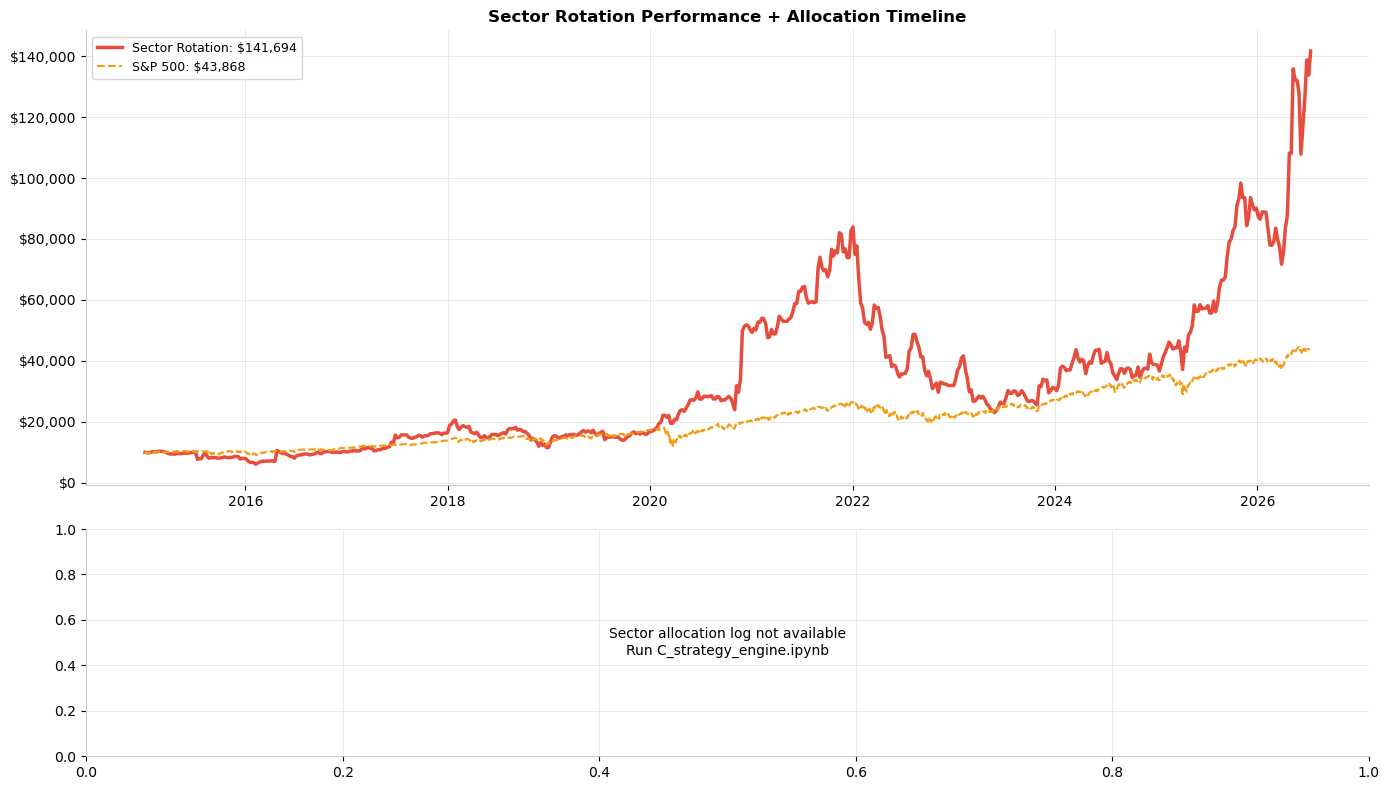

In [13]:
SECTOR_COLORS = {
    'AI Accelerators':'#8e44ad','Semiconductor Supply':'#6c3483',
    'Big Tech':'#2980b9','Cloud / SaaS':'#27ae60',
    'Cybersecurity':'#e74c3c','Enterprise AI':'#e67e22',
    'Macro Risk':'#95a5a6','Portfolio':'#1abc9c',
    'Consumer Tech':'#3498db','Enterprise Fintech':'#f39c12',
    'CASH/SPY':'#bdc3c7',
}

if not df_trades.empty and 'strategy' in df_trades.columns:
    # Build weekly sector allocation from trade log + equity curve
    fig, axes = plt.subplots(2,1, figsize=(14,8), facecolor='white',
                              gridspec_kw={'height_ratios':[2,1]})

    # Top: equity curve with sector color shading
    ax = axes[0]
    if not df_equity.empty:
        rot_col = [c for c in df_equity.columns if 'Rotation' in c]
        if rot_col:
            rot_s = df_equity.set_index('date')[rot_col[0]].dropna()
            ax.plot(rot_s.index, rot_s.values, color='#e74c3c', linewidth=2.5,
                    label=f'Sector Rotation: ${rot_s.iloc[-1]:,.0f}')
        spy_col = [c for c in df_equity.columns if 'SPY' in c]
        if spy_col:
            spy_s = df_equity.set_index('date')[spy_col[0]].dropna()
            ax.plot(spy_s.index, spy_s.values, color='#f39c12', linewidth=1.5,
                    linestyle='--', label=f'S&P 500: ${spy_s.iloc[-1]:,.0f}')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_title('Sector Rotation Performance + Allocation Timeline', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, facecolor='white')
    ax.set_facecolor('white')

    # Bottom: sector allocation timeline
    ax2 = axes[1]
    # Build from trade log sector-level entries
    if 'sector' in df_trades.columns:
        alloc_df = df_trades[df_trades['strategy']=='Sector_Rotation'][['entry_date','sector']].copy()
    else:
        alloc_df = pd.DataFrame()

    if not alloc_df.empty:
        alloc_df['entry_date'] = pd.to_datetime(alloc_df['entry_date'])
        for sector in alloc_df['sector'].unique():
            mask = alloc_df['sector']==sector
            c = SECTOR_COLORS.get(sector,'#888888')
            ax2.scatter(alloc_df.loc[mask,'entry_date'],
                        [sector]*mask.sum(), c=c, s=80, alpha=0.8,
                        edgecolors='white', linewidths=0.5)
        ax2.set_title('Sector chosen each week (dot = allocation event)', fontsize=10)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax2.set_facecolor('white')
    else:
        ax2.text(0.5,0.5,'Sector allocation log not available\nRun C_strategy_engine.ipynb',
                 ha='center',va='center',transform=ax2.transAxes, fontsize=10)
        ax2.set_facecolor('white')

    plt.tight_layout()
    plt.show()
else:
    print('No strategy data. Run C_strategy_engine.ipynb first.')